# PricePilot AI — Demand Prediction with Regularized XGBoost

This notebook keeps the original workflow and applies the final XGBoost overfitting/data-contract fixes.

**Run cells from top to bottom.**


# ML Model Included:


1.   Linear Regression
2.   Ridge Regression
3.   Lasso Regression
4.   Decision Tree
5.   Random Forest
6.   XG BOOST (Best model Till Now)
7.   LSTM



# Data loading and preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tkinter import Tk, filedialog
# Scikit-Learn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# XGBoost
from xgboost import XGBRegressor

# ==============================
# TensorFlow / LSTM
# ==============================
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==============================
# Version Check
# ==============================
print("Python environment ready")
print("TensorFlow:", tf.__version__)

import xgboost as xgb
print("XGBoost:", xgb.__version__)

Python environment ready
TensorFlow: 2.21.0
XGBoost: 3.4.1


# Uploading the Dataset

In [2]:
#GPU Activation Check

try:
    import torch

    if torch.cuda.is_available():
        print("GPU available:")
        print(torch.cuda.get_device_name(0))
    else:
        print("CUDA GPU not available.")
        print("Using CPU.")

except ImportError:
    print("PyTorch is not installed.")
    print("Scikit-learn models will run on CPU.")


GPU available:
NVIDIA GeForce RTX 2050


In [3]:
def select_dataset():

    root = Tk()
    root.withdraw()

    file_path = filedialog.askopenfilename(
        title="Select Dataset",
        filetypes=[
            ("CSV files", "*.csv"),
            ("Excel files", "*.xlsx"),
            ("All files", "*.*")
        ]
    )

    root.destroy()

    if not file_path:
        raise FileNotFoundError("No dataset selected.")

    return file_path

In [4]:
file_path = r"C:\Infosys_project\PRICEPILOT_AI\ML_MODEL\model_training\sales_cleaned.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (76000, 25)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Demand,Year,Month,Day,Revenue,Inventory Group,Price Difference,Relative Price Difference,Relative Price Difference %,Price Position
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,115,2022,1,1,7046.568,"(183.0, 287.0]",-13.01,-0.151756,-15.175551,Cheaper than Competitor
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,229,2022,1,1,7971.912,"(-0.001, 123.0]",-11.86,-0.128885,-12.888502,Cheaper than Competitor
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,157,2022,1,1,6457.644,"(183.0, 287.0]",2.86,0.047603,4.760320,Similar to Competitor
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,52,2022,1,1,3549.015,"(123.0, 183.0]",2.44,0.028642,2.864186,Similar to Competitor
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,59,2022,1,1,3536.650,"(123.0, 183.0]",2.78,0.053845,5.384466,More Expensive than Competitor


# Cleaned Dataset FROM EDA Inspection

In [5]:
# Local dataset path
file_name = r"C:\Infosys_project\PRICEPILOT_AI\ML_MODEL\model_training\sales_cleaned.csv"

# Load dataset
df = pd.read_csv(file_name)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset Shape:", df.shape)

display(df.head())

print("\nDataset Information:")

df.info()

Dataset Shape: (76000, 25)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Demand,Year,Month,Day,Revenue,Inventory Group,Price Difference,Relative Price Difference,Relative Price Difference %,Price Position
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,115,2022,1,1,7046.568,"(183.0, 287.0]",-13.01,-0.151756,-15.175551,Cheaper than Competitor
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,229,2022,1,1,7971.912,"(-0.001, 123.0]",-11.86,-0.128885,-12.888502,Cheaper than Competitor
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,157,2022,1,1,6457.644,"(183.0, 287.0]",2.86,0.047603,4.760320,Similar to Competitor
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,52,2022,1,1,3549.015,"(123.0, 183.0]",2.44,0.028642,2.864186,Similar to Competitor
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,59,2022,1,1,3536.650,"(123.0, 183.0]",2.78,0.053845,5.384466,More Expensive than Competitor



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         76000 non-null  datetime64[us]
 1   Store ID                     76000 non-null  str           
 2   Product ID                   76000 non-null  str           
 3   Category                     76000 non-null  str           
 4   Region                       76000 non-null  str           
 5   Inventory Level              76000 non-null  int64         
 6   Units Sold                   76000 non-null  int64         
 7   Units Ordered                76000 non-null  int64         
 8   Price                        76000 non-null  float64       
 9   Discount                     76000 non-null  int64         
 10  Weather Condition            76000 non-null  str           
 11  Promotion                    7

# Shape of  Cleaned Dataset

In [6]:
#shape Of Cleaned Dataset
df.shape

(76000, 25)

In [7]:
df = df.sort_values('Date').reset_index(drop=True)
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

print("\nDataset Shape:", df.shape)

Start Date: 2022-01-01 00:00:00
End Date: 2024-01-30 00:00:00

Dataset Shape: (76000, 25)


# Feature Engineering
# Create additional time-based features

In [8]:


df['Day of Week'] = df['Date'].dt.dayofweek

df['Quarter'] = df['Date'].dt.quarter

df['Week of Year'] = (
    df['Date'].dt.isocalendar().week.astype(int)
)

print(
    df[
        [
            'Date',
            'Year',
            'Month',
            'Day',
            'Day of Week',
            'Quarter',
            'Week of Year'
        ]
    ].head()
)

        Date  Year  Month  Day  Day of Week  Quarter  Week of Year
0 2022-01-01  2022      1    1            5        1            52
1 2022-01-01  2022      1    1            5        1            52
2 2022-01-01  2022      1    1            5        1            52
3 2022-01-01  2022      1    1            5        1            52
4 2022-01-01  2022      1    1            5        1            52


In [9]:
# Cyclical encoding for Month
df['Month Sin'] = np.sin(
    2 * np.pi * df['Month'] / 12
)
df['Month Cos'] = np.cos(
    2 * np.pi * df['Month'] / 12
)
# Cyclical encoding for Day of Week
df['DayOfWeek Sin'] = np.sin(
    2 * np.pi * df['Day of Week'] / 7
)
df['DayOfWeek Cos'] = np.cos(
    2 * np.pi * df['Day of Week'] / 7
)

In [10]:
print("Updated Dataset Shape:", df.shape)
print("\nNew Columns:")
print([
    'Day of Week',
    'Quarter',
    'Week of Year',
    'Month Sin',
    'Month Cos',
    'DayOfWeek Sin',
    'DayOfWeek Cos'
])

Updated Dataset Shape: (76000, 32)

New Columns:
['Day of Week', 'Quarter', 'Week of Year', 'Month Sin', 'Month Cos', 'DayOfWeek Sin', 'DayOfWeek Cos']


In [11]:
# ============================================
# TARGET AND FEATURE SELECTION
# ============================================

TARGET = "Demand"

target = TARGET

# Units Ordered is excluded because the intended application
# predicts demand before the next order quantity is known.
exclude_columns = [
    "Date",
    "Demand",
    "Units Sold",
    "Units Ordered",
    "Revenue",
    "Inventory Group",
    "Relative Price Difference %"
]

features = [
    column
    for column in df.columns
    if column not in exclude_columns
]

X = df[features].copy()
y = df[target].copy()

print("Number of Features:", len(features))
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures Used:")
for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")

print("\nExcluded Columns:")
for column in exclude_columns:
    print(f"- {column}")

Number of Features: 25
Feature Matrix Shape: (76000, 25)
Target Shape: (76000,)

Features Used:
1. Store ID
2. Product ID
3. Category
4. Region
5. Inventory Level
6. Price
7. Discount
8. Weather Condition
9. Promotion
10. Competitor Pricing
11. Seasonality
12. Epidemic
13. Year
14. Month
15. Day
16. Price Difference
17. Relative Price Difference
18. Price Position
19. Day of Week
20. Quarter
21. Week of Year
22. Month Sin
23. Month Cos
24. DayOfWeek Sin
25. DayOfWeek Cos

Excluded Columns:
- Date
- Demand
- Units Sold
- Units Ordered
- Revenue
- Inventory Group
- Relative Price Difference %


In [12]:
categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_features = X.select_dtypes(
    include=['int64', 'int32', 'float64']
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality', 'Price Position']

Numerical Features:
['Inventory Level', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic', 'Year', 'Month', 'Day', 'Price Difference', 'Relative Price Difference', 'Day of Week', 'Quarter', 'Week of Year', 'Month Sin', 'Month Cos', 'DayOfWeek Sin', 'DayOfWeek Cos']


C:\Users\Asus\AppData\Local\Temp\ipykernel_18260\1001862124.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


# Train,Test,Split Information

In [13]:
unique_dates = np.sort(df['Date'].unique())
total_dates = len(unique_dates)
train_end = int(total_dates * 0.70)
validation_end = int(total_dates * 0.85)
train_dates = unique_dates[:train_end]
validation_dates = unique_dates[
    train_end:validation_end
]
test_dates = unique_dates[
    validation_end:
]
train_df = df[df['Date'].isin(train_dates)].copy()
validation_df = df[
    df['Date'].isin(validation_dates)
].copy()
test_df = df[df['Date'].isin(test_dates)].copy()
print("Total Unique Dates:", total_dates)

print("\nTrain Shape:", train_df.shape)
print("Validation Shape:", validation_df.shape)
print("Test Shape:", test_df.shape)

print("\nTraining Period:")
print(train_df['Date'].min(), "to", train_df['Date'].max())

print("\nValidation Period:")
print(
    validation_df['Date'].min(),
    "to",
    validation_df['Date'].max()
)

print("\nTesting Period:")
print(test_df['Date'].min(), "to", test_df['Date'].max())

Total Unique Dates: 760

Train Shape: (53200, 32)
Validation Shape: (11400, 32)
Test Shape: (11400, 32)

Training Period:
2022-01-01 00:00:00 to 2023-06-16 00:00:00

Validation Period:
2023-06-17 00:00:00 to 2023-10-08 00:00:00

Testing Period:
2023-10-09 00:00:00 to 2024-01-30 00:00:00


# ==========================================
# DATASET CHRONOLOGICAL SPLIT ANALYSIS
# ==========================================

In [14]:


unique_dates = np.sort(df["Date"].unique())

total_dates = len(unique_dates)

train_end = int(total_dates * 0.70)
validation_end = int(total_dates * 0.85)

train_dates = unique_dates[:train_end]
validation_dates = unique_dates[train_end:validation_end]
test_dates = unique_dates[validation_end:]

train_df = df[df["Date"].isin(train_dates)].copy()
validation_df = df[df["Date"].isin(validation_dates)].copy()
test_df = df[df["Date"].isin(test_dates)].copy()


# ==========================================
# 1. DATASET OVERVIEW
# ==========================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("Total Records:", len(df))
print("Total Features:", df.shape[1])
print("Total Unique Dates:", total_dates)

print(
    "Overall Period:",
    df["Date"].min(),
    "to",
    df["Date"].max()
)


# ==========================================
# 2. SPLIT INFORMATION
# ==========================================

print("\n" + "=" * 60)
print("CHRONOLOGICAL SPLIT")
print("=" * 60)

print(
    f"Training:   {len(train_df):,} records "
    f"({len(train_df) / len(df) * 100:.2f}%)"
)

print(
    f"Validation: {len(validation_df):,} records "
    f"({len(validation_df) / len(df) * 100:.2f}%)"
)

print(
    f"Testing:    {len(test_df):,} records "
    f"({len(test_df) / len(df) * 100:.2f}%)"
)


# ==========================================
# 3. DATE RANGES
# ==========================================

print("\n" + "=" * 60)
print("DATE RANGES")
print("=" * 60)

print(
    "Training:",
    train_df["Date"].min(),
    "→",
    train_df["Date"].max()
)

print(
    "Validation:",
    validation_df["Date"].min(),
    "→",
    validation_df["Date"].max()
)

print(
    "Testing:",
    test_df["Date"].min(),
    "→",
    test_df["Date"].max()
)


# ==========================================
# 4. UNIQUE STORES & PRODUCTS
# ==========================================

print("\n" + "=" * 60)
print("STORE & PRODUCT COVERAGE")
print("=" * 60)

for name, data in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Testing", test_df)
]:
    print(f"\n{name}:")
    print("  Stores:", data["Store ID"].nunique())
    print("  Products:", data["Product ID"].nunique())


# ==========================================
# 5. DEMAND STATISTICS
# ==========================================

print("\n" + "=" * 60)
print("DEMAND DISTRIBUTION")
print("=" * 60)

for name, data in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Testing", test_df)
]:
    print(f"\n{name}:")
    print("  Mean:", round(data["Demand"].mean(), 2))
    print("  Median:", round(data["Demand"].median(), 2))
    print("  Std:", round(data["Demand"].std(), 2))
    print("  Min:", round(data["Demand"].min(), 2))
    print("  Max:", round(data["Demand"].max(), 2))


# ==========================================
# 6. DATE OVERLAP CHECK
# ==========================================

print("\n" + "=" * 60)
print("DATE OVERLAP CHECK")
print("=" * 60)

print(
    "Train ∩ Validation:",
    len(set(train_dates) & set(validation_dates))
)

print(
    "Validation ∩ Test:",
    len(set(validation_dates) & set(test_dates))
)

print(
    "Train ∩ Test:",
    len(set(train_dates) & set(test_dates))
)


# ==========================================
# 7. MISSING DATE CHECK
# ==========================================

print("\n" + "=" * 60)
print("MISSING DATE CHECK")
print("=" * 60)

expected_dates = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D"
)

missing_dates = expected_dates.difference(
    pd.DatetimeIndex(unique_dates)
)

print("Expected Calendar Dates:", len(expected_dates))
print("Actual Unique Dates:", len(unique_dates))
print("Missing Dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("First Missing Dates:")
    print(missing_dates[:10])


# ==========================================
# 8. FINAL SHAPES
# ==========================================

print("\n" + "=" * 60)
print("FINAL SPLIT SHAPES")
print("=" * 60)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

DATASET OVERVIEW
Total Records: 76000
Total Features: 32
Total Unique Dates: 760
Overall Period: 2022-01-01 00:00:00 to 2024-01-30 00:00:00

CHRONOLOGICAL SPLIT
Training:   53,200 records (70.00%)
Validation: 11,400 records (15.00%)
Testing:    11,400 records (15.00%)

DATE RANGES
Training: 2022-01-01 00:00:00 → 2023-06-16 00:00:00
Validation: 2023-06-17 00:00:00 → 2023-10-08 00:00:00
Testing: 2023-10-09 00:00:00 → 2024-01-30 00:00:00

STORE & PRODUCT COVERAGE

Training:
  Stores: 5
  Products: 20

Validation:
  Stores: 5
  Products: 20

Testing:
  Stores: 5
  Products: 20

DEMAND DISTRIBUTION

Training:
  Mean: 103.3
  Median: 99.0
  Std: 46.8
  Min: 4
  Max: 378

Validation:
  Mean: 114.64
  Median: 108.0
  Std: 48.2
  Min: 4
  Max: 430

Testing:
  Mean: 98.76
  Median: 96.0
  Std: 44.92
  Min: 4
  Max: 330

DATE OVERLAP CHECK
Train ∩ Validation: 0
Validation ∩ Test: 0
Train ∩ Test: 0

MISSING DATE CHECK
Expected Calendar Dates: 760
Actual Unique Dates: 760
Missing Dates: 0

FINAL SP

In [15]:
X_train = train_df[features].copy()
y_train = train_df[target].copy()

X_validation = validation_df[features].copy()
y_validation = validation_df[target].copy()

X_test = test_df[features].copy()
y_test = test_df[target].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (53200, 25)
y_train: (53200,)

X_validation: (11400, 25)
y_validation: (11400,)

X_test: (11400, 25)
y_test: (11400,)


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'numerical',
            StandardScaler(),
            numerical_features
        ),
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

In [17]:
X_train_processed = preprocessor.fit_transform(X_train)

X_validation_processed = preprocessor.transform(X_validation)

X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:")
print(X_train_processed.shape)

print("\nProcessed Validation Shape:")
print(X_validation_processed.shape)

print("\nProcessed Test Shape:")
print(X_test_processed.shape)

Processed Training Shape:
(53200, 63)

Processed Validation Shape:
(11400, 63)

Processed Test Shape:
(11400, 63)


In [18]:
feature_names = preprocessor.get_feature_names_out()

print("Total Processed Features:", len(feature_names))

print("\nFirst 20 Features:")

for feature in feature_names[:20]:
    print(feature)

Total Processed Features: 63

First 20 Features:
numerical__Inventory Level
numerical__Price
numerical__Discount
numerical__Promotion
numerical__Competitor Pricing
numerical__Epidemic
numerical__Year
numerical__Month
numerical__Day
numerical__Price Difference
numerical__Relative Price Difference
numerical__Day of Week
numerical__Quarter
numerical__Week of Year
numerical__Month Sin
numerical__Month Cos
numerical__DayOfWeek Sin
numerical__DayOfWeek Cos
categorical__Store ID_S001
categorical__Store ID_S002


# Linear Regression

In [19]:
def initialize_parameters(n_features):
    weights = np.zeros(n_features)
    bias = 0.0
    return weights, bias

In [20]:
weights = [0.0, 0.0, 0.0]
bias = 0.0

In [21]:
def predict(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    return predictions

In [22]:
def compute_cost(y_true, y_pred):
    n = len(y_true)
    cost = np.sum(
        (y_true - y_pred) ** 2
    ) / n
    return cost

In [23]:
def compute_gradients(X, y_true, y_pred):
    n = len(y_true)
    error = y_pred - y_true
    dw = (2 / n) * np.dot(
        X.T,
        error
    )
    db = (2 / n) * np.sum(error)
    return dw, db

In [24]:
def update_parameters(
    weights,
    bias,
    dw,
    db,
    learning_rate
):

    weights = (
        weights -
        learning_rate * dw
    )

    bias = (
        bias -
        learning_rate * db
    )

    return weights, bias

In [25]:
def gradient_descent(
    X,
    y,
    weights,
    bias,
    learning_rate,
    iterations
):

    cost_history = []

    for i in range(iterations):

        y_pred = predict(
            X,
            weights,
            bias
        )

        cost = compute_cost(
            y,
            y_pred
        )

        dw, db = compute_gradients(
            X,
            y,
            y_pred
        )

        weights, bias = update_parameters(
            weights,
            bias,
            dw,
            db,
            learning_rate
        )

        cost_history.append(cost)

    return (
        weights,
        bias,
        cost_history
    )

In [26]:
class LinearRegressionScratch:

    def __init__(
        self,
        learning_rate=0.01,
        iterations=1000
    ):

        self.learning_rate = learning_rate
        self.iterations = iterations

        self.weights = None
        self.bias = None
        self.cost_history = []


    def initialize_parameters(self, n_features):

        self.weights = np.zeros(n_features)

        self.bias = 0.0


    def predict_values(self, X):

        predictions = (
            np.dot(X, self.weights)
            + self.bias
        )

        return predictions


    def compute_cost(self, y_true, y_pred):

        cost = np.mean(
            (y_true - y_pred) ** 2
        )

        return cost


    def compute_gradients(
        self,
        X,
        y_true,
        y_pred
    ):

        n = len(y_true)

        error = y_pred - y_true

        dw = (
            2 / n
        ) * np.dot(
            X.T,
            error
        )

        db = (
            2 / n
        ) * np.sum(error)

        return dw, db


    def update_parameters(
        self,
        dw,
        db
    ):

        self.weights = (
            self.weights
            - self.learning_rate * dw
        )

        self.bias = (
            self.bias
            - self.learning_rate * db
        )


    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_features = X.shape[1]

        self.initialize_parameters(n_features)

        self.cost_history = []

        for iteration in range(self.iterations):

            y_pred = self.predict_values(X)

            cost = self.compute_cost(
                y,
                y_pred
            )

            dw, db = self.compute_gradients(
                X,
                y,
                y_pred
            )

            self.update_parameters(
                dw,
                db
            )

            self.cost_history.append(cost)

            if iteration % 100 == 0:

                print(
                    f"Iteration {iteration}: "
                    f"MSE = {cost:.4f}"
                )


    def predict(self, X):
        X = np.asarray(X, dtype=float)
        predictions = self.predict_values(X)
        return predictions

In [27]:
X_train_array = np.asarray(
    X_train_processed,
    dtype=float
)

X_validation_array = np.asarray(
    X_validation_processed,
    dtype=float
)

X_test_array = np.asarray(
    X_test_processed,
    dtype=float
)

y_train_array = np.asarray(
    y_train,
    dtype=float
)

y_validation_array = np.asarray(
    y_validation,
    dtype=float
)

y_test_array = np.asarray(
    y_test,
    dtype=float
)

In [28]:
linear_model = LinearRegressionScratch(
    learning_rate=0.01,
    iterations=1000
)

linear_model.fit(
    X_train_array,
    y_train_array
)

Iteration 0: MSE = 12860.5270
Iteration 100: MSE = 1430.6402
Iteration 200: MSE = 1337.1247
Iteration 300: MSE = 1291.6334
Iteration 400: MSE = 1264.5786
Iteration 500: MSE = 1246.7763
Iteration 600: MSE = 1234.1969
Iteration 700: MSE = 1224.8270
Iteration 800: MSE = 1217.5712
Iteration 900: MSE = 1211.7896


In [29]:
print("Final Training MSE:")

print(
    linear_model.cost_history[-1]
)

Final Training MSE:
1207.1271249256683


In [30]:
training_mse = linear_model.cost_history[-1]

training_rmse = np.sqrt(training_mse)

print("Final Training MSE:", training_mse)
print("Final Training RMSE:", training_rmse)

Final Training MSE: 1207.1271249256683
Final Training RMSE: 34.743735045698074


In [31]:
y_validation_pred = linear_model.predict(
    X_validation_array
)

print("First 10 Actual Values:")
print(y_validation_array[:10])

print("\nFirst 10 Predicted Values:")
print(
    np.round(y_validation_pred[:10], 2)
)

First 10 Actual Values:
[ 82. 214. 170.  79. 111. 109.  72.  86.  67. 196.]

First 10 Predicted Values:
[116.13 150.29 149.39  75.01 114.11 113.97 134.78 106.93 124.92 156.01]


In [32]:
def mean_absolute_error(
    y_true,
    y_pred
):

    return np.mean(
        np.abs(y_true - y_pred)
    )


def mean_squared_error(
    y_true,
    y_pred
):

    return np.mean(
        (y_true - y_pred) ** 2
    )


def root_mean_squared_error(
    y_true,
    y_pred
):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    return np.sqrt(mse)


def r2_score(
    y_true,
    y_pred
):

    total_variance = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    residual_variance = np.sum(
        (y_true - y_pred) ** 2
    )

    return (
        1 -
        residual_variance / total_variance
    )


def mean_absolute_percentage_error(
    y_true,
    y_pred
):

    mask = y_true != 0

    return np.mean(
        np.abs(
            (
                y_true[mask]
                - y_pred[mask]
            )
            / y_true[mask]
        )
    ) * 100

In [33]:
validation_mae = mean_absolute_error(
    y_validation_array,
    y_validation_pred
)

validation_mse = mean_squared_error(
    y_validation_array,
    y_validation_pred
)

validation_rmse = root_mean_squared_error(
    y_validation_array,
    y_validation_pred
)

validation_r2 = r2_score(
    y_validation_array,
    y_validation_pred
)

validation_mape = mean_absolute_percentage_error(
    y_validation_array,
    y_validation_pred
)

print("VALIDATION PERFORMANCE")
print("-" * 40)

print(
    f"MAE:   {validation_mae:.4f}"
)

print(
    f"MSE:   {validation_mse:.4f}"
)

print(
    f"RMSE:  {validation_rmse:.4f}"
)

print(
    f"R²:    {validation_r2:.4f}"
)

print(
    f"MAPE:  {validation_mape:.2f}%"
)

VALIDATION PERFORMANCE
----------------------------------------
MAE:   28.8396
MSE:   1418.4560
RMSE:  37.6624
R²:    0.3894
MAPE:  35.52%


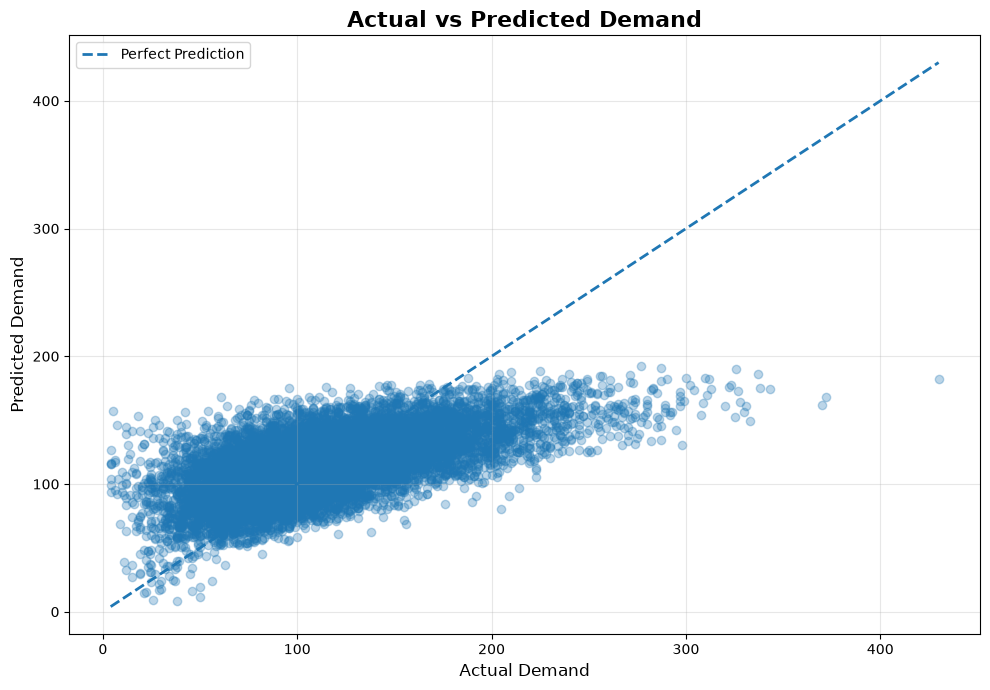

In [34]:
plt.figure(figsize=(10, 7))

plt.scatter(
    y_validation_array,
    y_validation_pred,
    alpha=0.3
)

min_value = min(
    y_validation_array.min(),
    y_validation_pred.min()
)

max_value = max(
    y_validation_array.max(),
    y_validation_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.title(
    'Actual vs Predicted Demand',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Actual Demand',
    fontsize=12
)

plt.ylabel(
    'Predicted Demand',
    fontsize=12
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#Residual Analysis

In [35]:
y_validation_array = np.asarray(
    y_validation,
    dtype=float
)

y_validation_pred = linear_model.predict(
    X_validation_processed
)

residuals = (
    y_validation_array -
    y_validation_pred
)

analysis_df = pd.DataFrame({

    'Actual Demand':
        y_validation_array,

    'Predicted Demand':
        y_validation_pred,

    'Residual':
        residuals,

    'Absolute Error':
        np.abs(residuals),

    'Squared Error':
        residuals ** 2

})

display(
    analysis_df.head()
)

,Actual Demand,Predicted Demand,Residual,Absolute Error,Squared Error
0,82.0,116.128572,-34.128572,34.128572,1164.759393
1,214.0,150.285929,63.714071,63.714071,4059.482856
2,170.0,149.394811,20.605189,20.605189,424.573825
3,79.0,75.013720,3.986280,3.986280,15.890431
4,111.0,114.105289,-3.105289,3.105289,9.642820


In [36]:
print(
    analysis_df[
        'Residual'
    ].describe()
)

count    11400.000000
mean         0.098056
std         37.663919
min       -152.547498
25%        -23.891635
50%         -2.234027
75%         21.710198
max        247.836744
Name: Residual, dtype: float64


In [37]:
print(
    "\nMean Residual:",
    analysis_df['Residual'].mean()
)

print(
    "Median Residual:",
    analysis_df['Residual'].median()
)

print(
    "Standard Deviation:",
    analysis_df['Residual'].std()
)

print(
    "Maximum Error:",
    analysis_df['Residual'].max()
)

print(
    "Minimum Error:",
    analysis_df['Residual'].min()
)


Mean Residual: 0.09805627056842839
Median Residual: -2.2340267406011023
Standard Deviation: 37.66391943327756
Maximum Error: 247.83674432485685
Minimum Error: -152.5474977432524


In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# Convert to NumPy arrays

y_validation_array = np.asarray(
    y_validation,
    dtype=float
)

y_validation_pred = np.asarray(
    y_validation_pred,
    dtype=float
)


# MAE

mae = mean_absolute_error(
    y_validation_array,
    y_validation_pred
)


# MSE

mse = mean_squared_error(
    y_validation_array,
    y_validation_pred
)


# RMSE

rmse = np.sqrt(mse)


# R² Score

r2 = r2_score(
    y_validation_array,
    y_validation_pred
)


# MAPE

mape = mean_absolute_percentage_error(
    y_validation_array,
    y_validation_pred
) * 100


print("=" * 50)

print("LINEAR REGRESSION PERFORMANCE")

print("=" * 50)

print(f"MAE:   {mae:.4f}")

print(f"MSE:   {mse:.4f}")

print(f"RMSE:  {rmse:.4f}")

print(f"R²:    {r2:.4f}")

print(f"R² Percentage: {r2 * 100:.2f}%")

print(f"MAPE:  {mape:.2f}%")

print("=" * 50)

LINEAR REGRESSION PERFORMANCE
MAE:   28.8396
MSE:   1418.4560
RMSE:  37.6624
R²:    0.3894
R² Percentage: 38.94%
MAPE:  35.52%


# Ridge Regression

In [39]:
X_train_processed
X_validation_processed
X_test_processed

y_train_array
y_validation_array
y_test_array

array([133.,  47., 146., ..., 118., 105.,  73.], shape=(11400,))

In [40]:
ridge_model = Ridge(
    alpha=1.0
)
ridge_model.fit(
    X_train_processed,
    y_train_array
)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [41]:
ridge_validation_pred = ridge_model.predict(
    X_validation_processed
)

#Reusable Evaluation Function

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_regression_model(
    y_true,
    y_pred,
    model_name
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    mask = y_true != 0

    mape = np.mean(
        np.abs(
            (
                y_true[mask]
                - y_pred[mask]
            )
            / y_true[mask]
        )
    ) * 100

    results = {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape
    }

    return results

In [43]:
ridge_results = evaluate_regression_model(
    y_validation_array,
    ridge_validation_pred,
    'Ridge Regression'
)

ridge_results

{'Model': 'Ridge Regression',
 'MAE': 28.347032693167193,
 'MSE': 1372.0802694303582,
 'RMSE': np.float64(37.04160187451885),
 'R²': 0.4093678777562286,
 'MAPE (%)': np.float64(34.493776290772104)}

In [44]:
ridge_results_df = pd.DataFrame(
    [ridge_results]
)

display(
    ridge_results_df.round(4)
)

,Model,MAE,MSE,RMSE,R²,MAPE (%)
0,Ridge Regression,28.347,1372.0803,37.0416,0.4094,34.4938


In [45]:
linear_results = evaluate_regression_model(
    y_validation_array,
    y_validation_pred,
    'Linear Regression'
)

In [46]:
model_comparison = pd.DataFrame(
    [
        linear_results,
        ridge_results
    ]
)

display(
    model_comparison.round(4)
)

,Model,MAE,MSE,RMSE,R²,MAPE (%)
0,Linear Regression,28.8396,1418.4560,37.6624,0.3894,35.5202
1,Ridge Regression,28.3470,1372.0803,37.0416,0.4094,34.4938


In [47]:
alpha_values = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

ridge_alpha_results = []

for alpha in alpha_values:

    model = Ridge(
        alpha=alpha
    )

    model.fit(
        X_train_processed,
        y_train_array
    )

    predictions = model.predict(
        X_validation_processed
    )

    results = evaluate_regression_model(
        y_validation_array,
        predictions,
        f'Ridge alpha={alpha}'
    )

    results['Alpha'] = alpha

    ridge_alpha_results.append(
        results
    )

In [48]:
ridge_alpha_df = pd.DataFrame(
    ridge_alpha_results
)

ridge_alpha_df = ridge_alpha_df[
    [
        'Alpha',
        'MAE',
        'RMSE',
        'R²',
        'MAPE (%)'
    ]
]

display(
    ridge_alpha_df.round(4)
)

,Alpha,MAE,RMSE,R²,MAPE (%)
0,0.001,28.3468,37.0413,0.4094,34.4931
1,0.010,28.3468,37.0413,0.4094,34.4931
2,0.100,28.3469,37.0413,0.4094,34.4932
3,1.000,28.3470,37.0416,0.4094,34.4938
4,10.000,28.3488,37.0448,0.4093,34.4998
5,100.000,28.3704,37.0794,0.4082,34.5612
6,1000.000,28.6752,37.5215,0.3940,35.1146


#Best Alpha

In [49]:
best_ridge_row = ridge_alpha_df.loc[
    ridge_alpha_df['RMSE'].idxmin()
]

print("Best Ridge Configuration")
print("-" * 40)

print(
    "Best Alpha:",
    best_ridge_row['Alpha']
)

print(
    "Validation RMSE:",
    round(
        best_ridge_row['RMSE'],
        4
    )
)

print(
    "Validation R²:",
    round(
        best_ridge_row['R²'],
        4
    )
)

Best Ridge Configuration
----------------------------------------
Best Alpha: 0.001
Validation RMSE: 37.0413
Validation R²: 0.4094


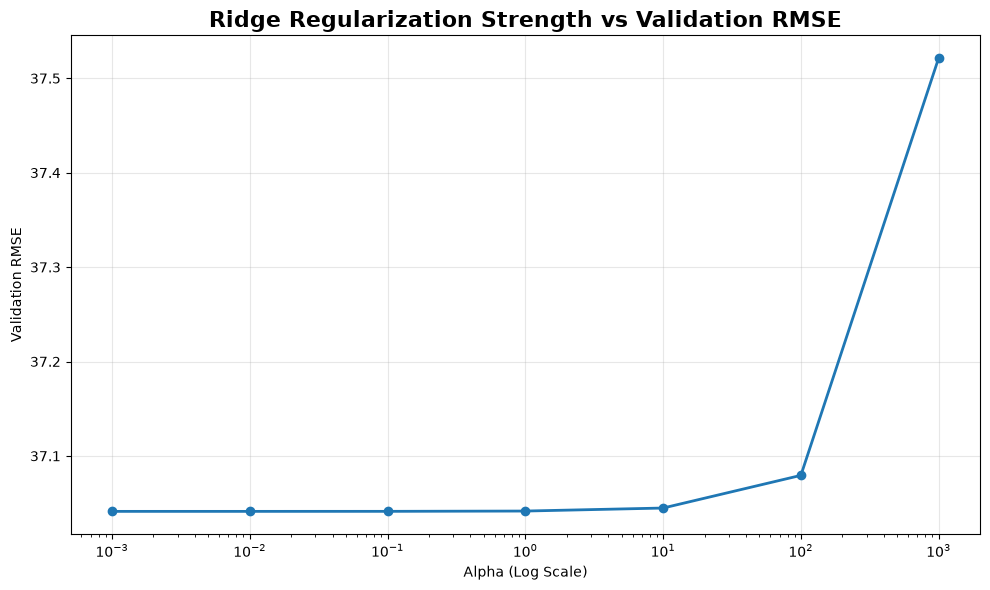

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(
    ridge_alpha_df['Alpha'],
    ridge_alpha_df['RMSE'],
    marker='o',
    linewidth=2
)

plt.xscale('log')

plt.title(
    'Ridge Regularization Strength vs Validation RMSE',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Alpha (Log Scale)'
)

plt.ylabel(
    'Validation RMSE'
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [51]:
best_alpha = ridge_alpha_df.loc[
    ridge_alpha_df['RMSE'].idxmin(),
    'Alpha'
]

best_ridge_model = Ridge(
    alpha=best_alpha
)

best_ridge_model.fit(
    X_train_processed,
    y_train_array
)

best_ridge_validation_pred = (
    best_ridge_model.predict(
        X_validation_processed
    )
)

In [52]:
best_ridge_results = evaluate_regression_model(
    y_validation_array,
    best_ridge_validation_pred,
    'Best Ridge Regression'
)

display(
    pd.DataFrame(
        [best_ridge_results]
    ).round(4)
)

,Model,MAE,MSE,RMSE,R²,MAPE (%)
0,Best Ridge Regression,28.3468,1372.0543,37.0413,0.4094,34.4931


In [53]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

In [54]:
ridge_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient':
        best_ridge_model.coef_
})

ridge_coefficients[
    'Absolute Coefficient'
] = (
    ridge_coefficients[
        'Coefficient'
    ].abs()
)

ridge_coefficients = (
    ridge_coefficients
    .sort_values(
        'Absolute Coefficient',
        ascending=False
    )
)

In [55]:
display(
    ridge_coefficients[
        [
            'Feature',
            'Coefficient'
        ]
    ]
    .head(20)
    .round(4)
)

,Feature,Coefficient
45,categorical__Category_Furniture,-51.2433
46,categorical__Category_Groceries,29.0846
36,categorical__Product ID_P0014,-18.7951
5,numerical__Epidemic,-16.0247
47,categorical__Category_Toys,15.1315
43,categorical__Category_Clothing,14.2686
3,numerical__Promotion,11.9678
24,categorical__Product ID_P0002,11.8055
55,categorical__Weather Condition_Sunny,11.7023
31,categorical__Product ID_P0009,-11.0603


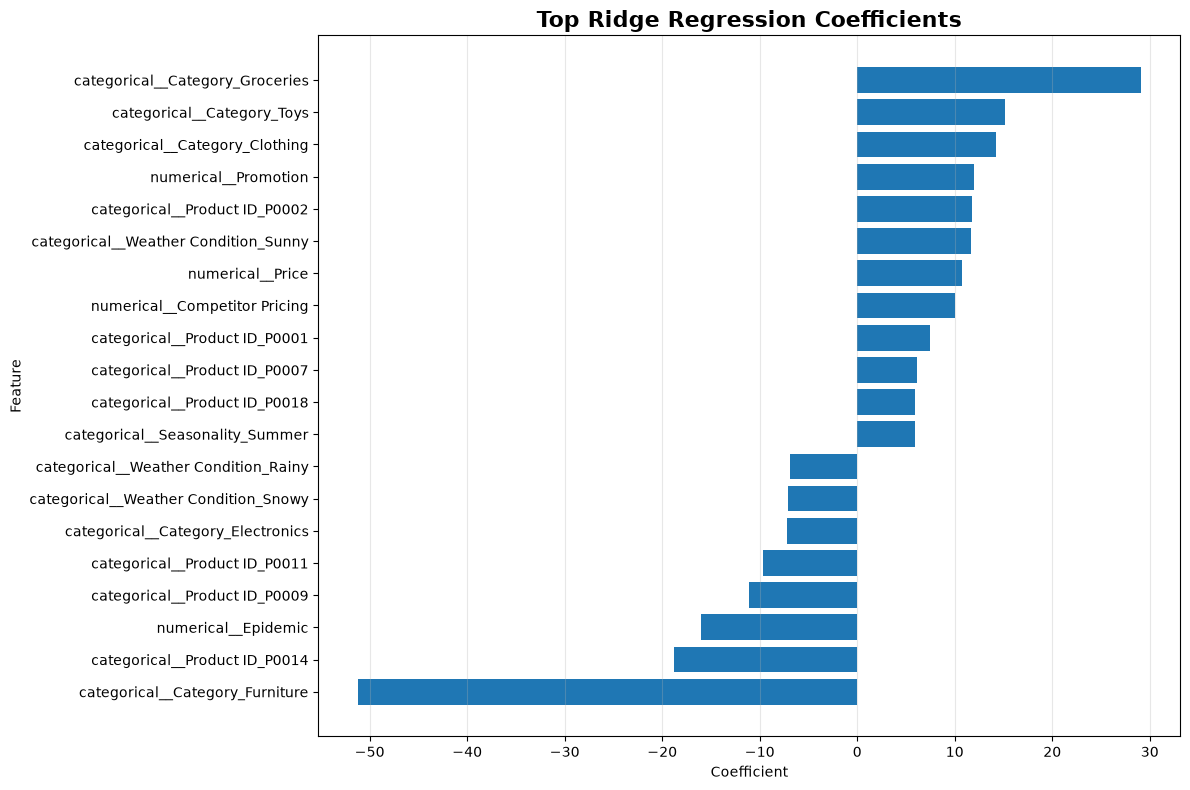

In [56]:
top_ridge_features = (
    ridge_coefficients
    .head(20)
    .sort_values(
        'Coefficient'
    )
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_ridge_features['Feature'],
    top_ridge_features['Coefficient']
)

plt.title(
    'Top Ridge Regression Coefficients',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Coefficient'
)

plt.ylabel(
    'Feature'
)

plt.grid(
    axis='x',
    alpha=0.3
)

plt.tight_layout()

plt.show()

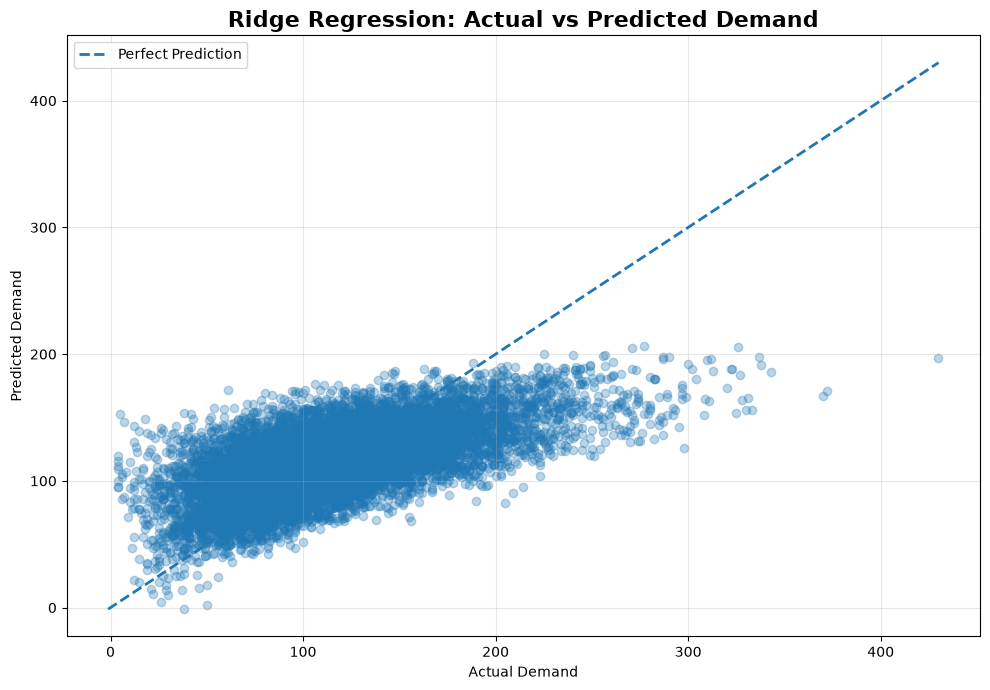

In [57]:
plt.figure(figsize=(10, 7))

plt.scatter(
    y_validation_array,
    best_ridge_validation_pred,
    alpha=0.3
)

minimum = min(
    y_validation_array.min(),
    best_ridge_validation_pred.min()
)

maximum = max(
    y_validation_array.max(),
    best_ridge_validation_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.title(
    'Ridge Regression: Actual vs Predicted Demand',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [58]:
ridge_residuals = (
    y_validation_array
    - best_ridge_validation_pred
)

print(
    "Mean Residual:",
    ridge_residuals.mean()
)

print(
    "Residual Standard Deviation:",
    ridge_residuals.std()
)

print(
    "Maximum Underprediction:",
    ridge_residuals.max()
)

print(
    "Maximum Overprediction:",
    ridge_residuals.min()
)

Mean Residual: 0.3030289723261609
Residual Standard Deviation: 37.04001189673496
Maximum Underprediction: 232.72245146170133
Maximum Overprediction: -147.44796188518993


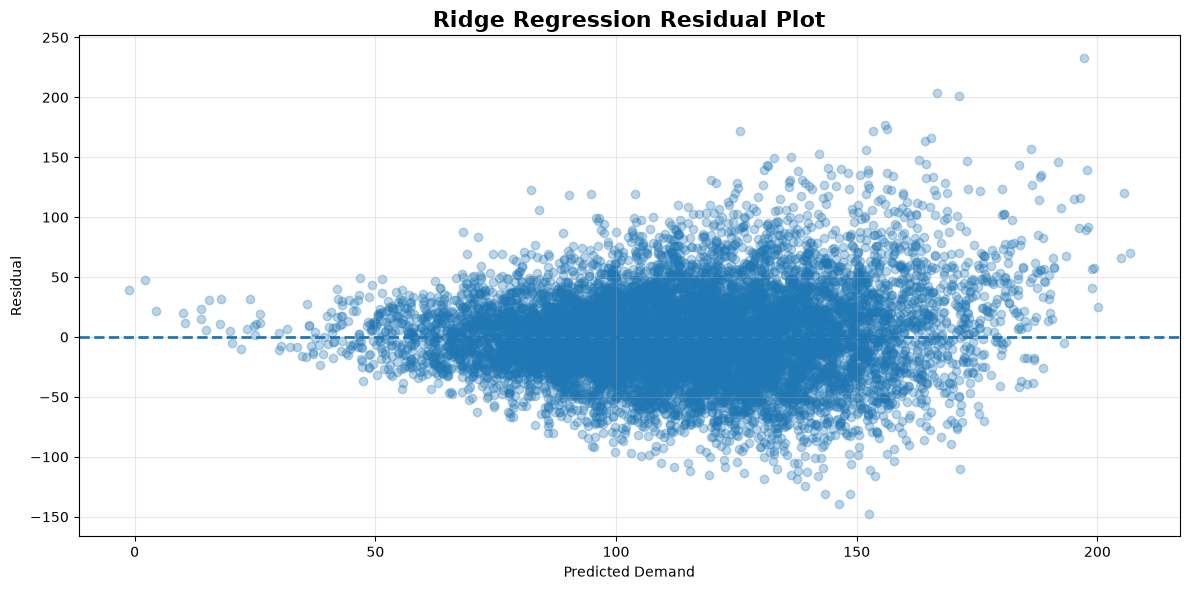

In [59]:
plt.figure(figsize=(12, 6))

plt.scatter(
    best_ridge_validation_pred,
    ridge_residuals,
    alpha=0.3
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=2
)

plt.title(
    'Ridge Regression Residual Plot',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Predicted Demand')
plt.ylabel('Residual')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [60]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_regression_model(
    y_true,
    y_pred,
    model_name
):

    # Convert to NumPy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # MAE
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    # MSE
    mse = mean_squared_error(
        y_true,
        y_pred
    )

    # RMSE
    rmse = np.sqrt(mse)

    # R² Score
    r2 = r2_score(
        y_true,
        y_pred
    )

    # Avoid division by zero
    mask = y_true != 0

    # MAPE
    mape = np.mean(
        np.abs(
            (y_true[mask] - y_pred[mask])
            / y_true[mask]
        )
    ) * 100

    # Accuracy-like metric
    accuracy = 100 - mape

    # Prevent negative accuracy
    accuracy = max(0, accuracy)

    results = {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'Prediction Accuracy (%)': accuracy
    }

    return results

In [61]:
linear_results = evaluate_regression_model(

    y_validation_array,

    y_validation_pred,

    'Linear Regression'

)

In [62]:
ridge_results = evaluate_regression_model(

    y_validation_array,

    ridge_validation_pred,

    'Ridge Regression'

)

In [63]:
model_comparison = pd.DataFrame(

    [

        linear_results,

        ridge_results

    ]

)

In [64]:
display(

    model_comparison.round(4)

)

,Model,MAE,MSE,RMSE,R²,MAPE (%),Prediction Accuracy (%)
0,Linear Regression,28.8396,1418.4560,37.6624,0.3894,35.5202,64.4798
1,Ridge Regression,28.3470,1372.0803,37.0416,0.4094,34.4938,65.5062


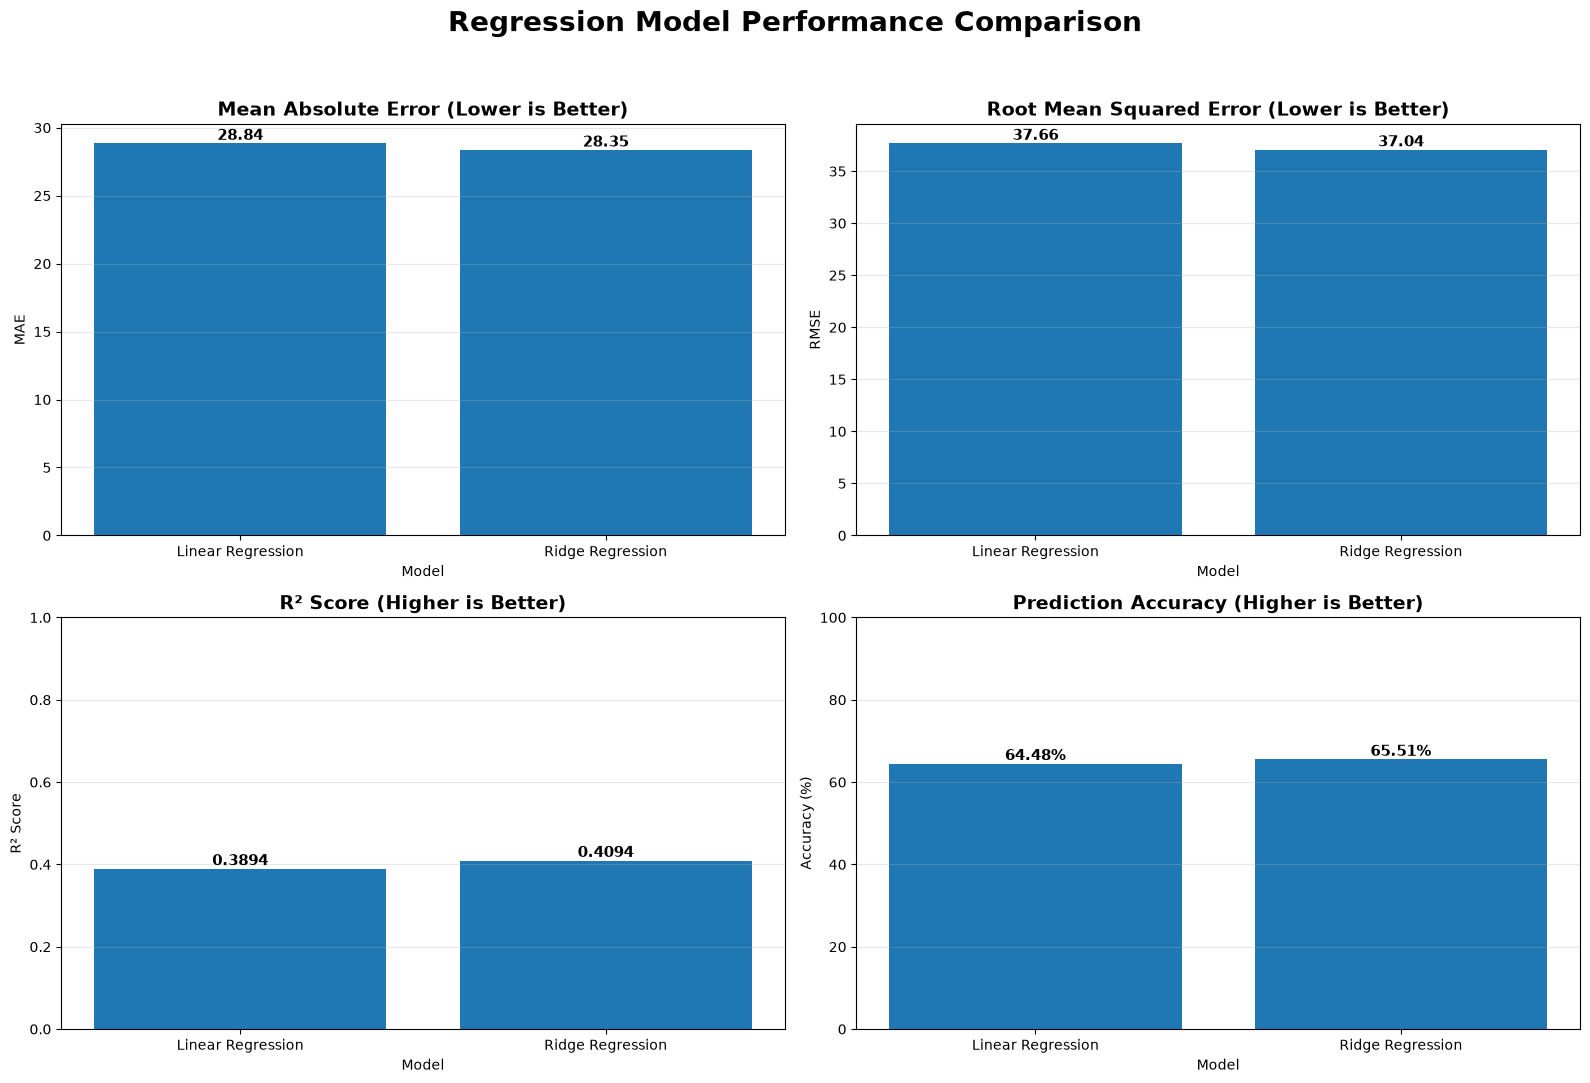

In [65]:
# ==========================================
# MODEL COMPARISON VISUALIZATION DASHBOARD
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11)
)


# ==========================================
# 1. MAE COMPARISON
# ==========================================

bars1 = axes[0, 0].bar(
    model_comparison['Model'],
    model_comparison['MAE']
)

axes[0, 0].set_title(
    'Mean Absolute Error (Lower is Better)',
    fontsize=14,
    fontweight='bold'
)

axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('MAE')

axes[0, 0].grid(
    axis='y',
    alpha=0.3
)

for bar in bars1:

    height = bar.get_height()

    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )


# ==========================================
# 2. RMSE COMPARISON
# ==========================================

bars2 = axes[0, 1].bar(
    model_comparison['Model'],
    model_comparison['RMSE']
)

axes[0, 1].set_title(
    'Root Mean Squared Error (Lower is Better)',
    fontsize=14,
    fontweight='bold'
)

axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('RMSE')

axes[0, 1].grid(
    axis='y',
    alpha=0.3
)

for bar in bars2:

    height = bar.get_height()

    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )


# ==========================================
# 3. R² SCORE COMPARISON
# ==========================================

bars3 = axes[1, 0].bar(
    model_comparison['Model'],
    model_comparison['R²']
)

axes[1, 0].set_title(
    'R² Score (Higher is Better)',
    fontsize=14,
    fontweight='bold'
)

axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('R² Score')

axes[1, 0].set_ylim(
    0,
    1
)

axes[1, 0].grid(
    axis='y',
    alpha=0.3
)

for bar in bars3:

    height = bar.get_height()

    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )


# ==========================================
# 4. PREDICTION ACCURACY COMPARISON
# ==========================================

bars4 = axes[1, 1].bar(
    model_comparison['Model'],
    model_comparison['Prediction Accuracy (%)']
)

axes[1, 1].set_title(
    'Prediction Accuracy (Higher is Better)',
    fontsize=14,
    fontweight='bold'
)

axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('Accuracy (%)')

axes[1, 1].set_ylim(
    0,
    100
)

axes[1, 1].grid(
    axis='y',
    alpha=0.3
)

for bar in bars4:

    height = bar.get_height()

    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )


# ==========================================
# MAIN TITLE
# ==========================================

fig.suptitle(
    'Regression Model Performance Comparison',
    fontsize=20,
    fontweight='bold',
    y=0.98
)


plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

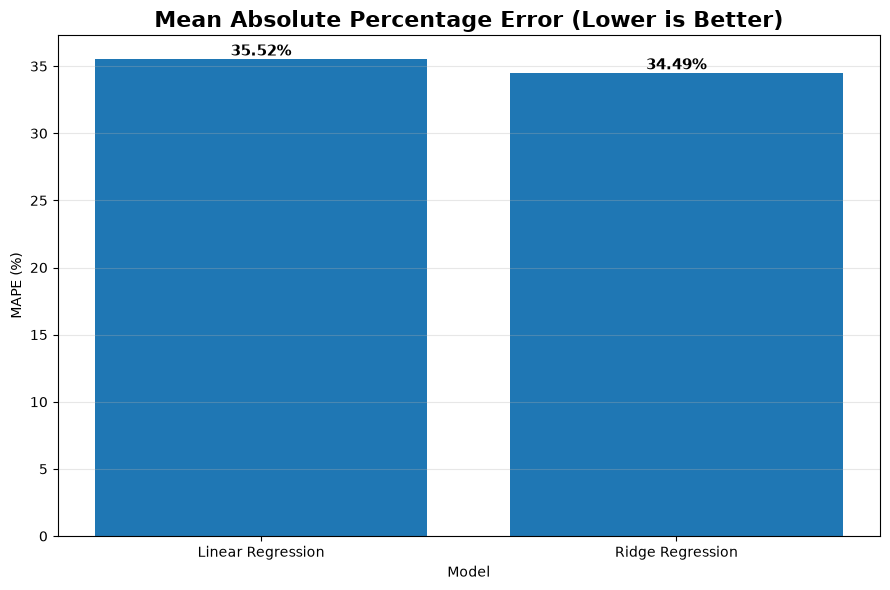

In [66]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    model_comparison['Model'],
    model_comparison['MAPE (%)']
)

plt.title(
    'Mean Absolute Percentage Error (Lower is Better)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Model')
plt.ylabel('MAPE (%)')

plt.grid(
    axis='y',
    alpha=0.3
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()

plt.show()

#Lasso Regression

In [67]:
lasso_model = Lasso(
    alpha=1.0,
    max_iter=10000,
    random_state=42
)

lasso_model.fit(
    X_train_processed,
    y_train
)

,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [68]:
y_lasso_pred = lasso_model.predict(
    X_validation_processed
)

y_validation_array = np.asarray(
    y_validation,
    dtype=float
)

In [69]:
lasso_results = evaluate_regression_model(
    y_validation_array,
    y_lasso_pred,
    'Lasso Regression'
)

lasso_results

{'Model': 'Lasso Regression',
 'MAE': 29.741617565857567,
 'MSE': 1529.4177176055398,
 'RMSE': np.float64(39.107770552737215),
 'R²': 0.3416396602498959,
 'MAPE (%)': np.float64(35.80527359949187),
 'Prediction Accuracy (%)': np.float64(64.19472640050813)}

In [70]:
model_comparison = pd.DataFrame(
    [
        linear_results,
        ridge_results,
        lasso_results
    ]
)

display(
    model_comparison.round(4)
)

,Model,MAE,MSE,RMSE,R²,MAPE (%),Prediction Accuracy (%)
0,Linear Regression,28.8396,1418.4560,37.6624,0.3894,35.5202,64.4798
1,Ridge Regression,28.3470,1372.0803,37.0416,0.4094,34.4938,65.5062
2,Lasso Regression,29.7416,1529.4177,39.1078,0.3416,35.8053,64.1947


In [71]:
lasso_coefficients = lasso_model.coef_

selected_features = np.sum(
    lasso_coefficients != 0
)

removed_features = np.sum(
    lasso_coefficients == 0
)

print("Total Features:", len(lasso_coefficients))

print("Selected Features:", selected_features)

print("Removed Features:", removed_features)

Total Features: 63
Selected Features: 14
Removed Features: 49


In [72]:
lasso_feature_importance = pd.DataFrame({

    'Feature': feature_names,

    'Coefficient': lasso_model.coef_

})

removed_features_df = lasso_feature_importance[
    lasso_feature_importance['Coefficient'] == 0
]

display(removed_features_df)

,Feature,Coefficient
6,numerical__Year,0.0
7,numerical__Month,-0.0
8,numerical__Day,-0.0
9,numerical__Price Difference,-0.0
10,numerical__Relative Price Difference,0.0
11,numerical__Day of Week,0.0
12,numerical__Quarter,-0.0
13,numerical__Week of Year,-0.0
14,numerical__Month Sin,-0.0
16,numerical__DayOfWeek Sin,-0.0


In [73]:
important_features = (
    lasso_feature_importance
    .assign(
        Absolute_Coefficient=lambda x:
        np.abs(x['Coefficient'])
    )
    .sort_values(
        'Absolute_Coefficient',
        ascending=False
    )
)

display(
    important_features.head(20)
)

,Feature,Coefficient,Absolute_Coefficient
45,categorical__Category_Furniture,-34.807118,34.807118
46,categorical__Category_Groceries,18.082967,18.082967
5,numerical__Epidemic,-16.244012,16.244012
3,numerical__Promotion,12.141421,12.141421
55,categorical__Weather Condition_Sunny,9.954092,9.954092
1,numerical__Price,7.304384,7.304384
43,categorical__Category_Clothing,4.263961,4.263961
53,categorical__Weather Condition_Rainy,-2.251271,2.251271
4,numerical__Competitor Pricing,0.979195,0.979195
15,numerical__Month Cos,-0.772342,0.772342


#Searching For the Best Alpha

In [74]:
from sklearn.linear_model import Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

alpha_values = [
    0.001,
    0.01,
    0.1,
    0.5,
    1,
    5,
    10
]

results = []

for alpha in alpha_values:

    model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    model.fit(
        X_train_processed,
        y_train
    )

    predictions = model.predict(
        X_validation_processed
    )

    mae = mean_absolute_error(
        y_validation,
        predictions
    )

    mse = mean_squared_error(
        y_validation,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_validation,
        predictions
    )

    results.append({

        'Alpha': alpha,

        'MAE': mae,

        'RMSE': rmse,

        'R2 Score': r2

    })


alpha_results = pd.DataFrame(results)

display(
    alpha_results.sort_values(
        'RMSE'
    ).round(4)
)

,Alpha,MAE,RMSE,R2 Score
0,0.001,28.3473,37.0423,0.4093
1,0.010,28.3529,37.0535,0.4090
2,0.100,28.4375,37.2008,0.4043
3,0.500,29.0693,38.1127,0.3747
4,1.000,29.7416,39.1078,0.3416
5,5.000,34.5151,45.0662,0.1257
6,10.000,36.2915,47.6374,0.0231


#Best Alpha Value


In [75]:
best_alpha = alpha_results.loc[
    alpha_results['RMSE'].idxmin(),
    'Alpha'
]

print("Best Alpha:", best_alpha)

Best Alpha: 0.001


#tuning the Lasso Regression

In [76]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(
    alpha=0.001,
    max_iter=10000
)

lasso_model.fit(
    X_train_processed,
    y_train
)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.001
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [77]:
y_lasso_pred = lasso_model.predict(
    X_validation_processed
)

In [78]:
lasso_results = evaluate_regression_model(
    y_validation_array,
    y_lasso_pred,
    'Lasso Regression'
)

print(lasso_results)

{'Model': 'Lasso Regression', 'MAE': 28.347265521182766, 'MSE': 1372.1342884318801, 'RMSE': np.float64(37.04233103399245), 'R²': 0.4093446244829172, 'MAPE (%)': np.float64(34.49519285875449), 'Prediction Accuracy (%)': np.float64(65.50480714124551)}


# **Comparison Chart**


In [79]:
model_comparison = pd.DataFrame([
    linear_results,
    ridge_results,
    lasso_results
])

display(model_comparison.round(4))

,Model,MAE,MSE,RMSE,R²,MAPE (%),Prediction Accuracy (%)
0,Linear Regression,28.8396,1418.4560,37.6624,0.3894,35.5202,64.4798
1,Ridge Regression,28.3470,1372.0803,37.0416,0.4094,34.4938,65.5062
2,Lasso Regression,28.3473,1372.1343,37.0423,0.4093,34.4952,65.5048


#DECISION TREE

In [80]:
decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

decision_tree_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with

In [81]:
y_tree_pred = decision_tree_model.predict(
    X_validation_processed
)

In [82]:
tree_results = evaluate_regression_model(
    y_validation_array,
    y_tree_pred,
    'Decision Tree'
)

print(tree_results)

{'Model': 'Decision Tree', 'MAE': 20.061842105263157, 'MSE': 1005.8755263157894, 'RMSE': np.float64(31.715540769720285), 'R²': 0.567006092823114, 'MAPE (%)': np.float64(22.206678849878315), 'Prediction Accuracy (%)': np.float64(77.79332115012168)}


In [83]:
model_comparison = pd.DataFrame([
    linear_results,
    ridge_results,
    lasso_results,
    tree_results
])

display(
    model_comparison.round(4)
)

,Model,MAE,MSE,RMSE,R²,MAPE (%),Prediction Accuracy (%)
0,Linear Regression,28.8396,1418.4560,37.6624,0.3894,35.5202,64.4798
1,Ridge Regression,28.3470,1372.0803,37.0416,0.4094,34.4938,65.5062
2,Lasso Regression,28.3473,1372.1343,37.0423,0.4093,34.4952,65.5048
3,Decision Tree,20.0618,1005.8755,31.7155,0.5670,22.2067,77.7933


In [84]:
y_tree_train_pred = decision_tree_model.predict(
    X_train_processed
)

tree_train_results = evaluate_regression_model(
    np.asarray(y_train, dtype=float),
    y_tree_train_pred,
    'Decision Tree - Training'
)

print(tree_train_results)

{'Model': 'Decision Tree - Training', 'MAE': 0.0, 'MSE': 0.0, 'RMSE': np.float64(0.0), 'R²': 1.0, 'MAPE (%)': np.float64(0.0), 'Prediction Accuracy (%)': np.float64(100.0)}


In [85]:
tree_overfitting_check = pd.DataFrame([
    tree_train_results,
    tree_results
])

display(
    tree_overfitting_check.round(4)
)

,Model,MAE,MSE,RMSE,R²,MAPE (%),Prediction Accuracy (%)
0,Decision Tree - Training,0.0000,0.0000,0.0000,1.000,0.0000,100.0000
1,Decision Tree,20.0618,1005.8755,31.7155,0.567,22.2067,77.7933


In [86]:
# Predict on training data

y_tree_train_pred = decision_tree_model.predict(
    X_train_processed
)

# Convert target to NumPy array

y_train_array = np.asarray(
    y_train,
    dtype=float
)

# Evaluate training performance

tree_train_results = evaluate_regression_model(
    y_train_array,
    y_tree_train_pred,
    'Decision Tree - Training'
)

print(tree_train_results)

{'Model': 'Decision Tree - Training', 'MAE': 0.0, 'MSE': 0.0, 'RMSE': np.float64(0.0), 'R²': 1.0, 'MAPE (%)': np.float64(0.0), 'Prediction Accuracy (%)': np.float64(100.0)}


In [87]:
tree_overfitting_check = pd.DataFrame([
    tree_train_results,
    tree_results
])

display(
    tree_overfitting_check.round(4)
)

,Model,MAE,MSE,RMSE,R²,MAPE (%),Prediction Accuracy (%)
0,Decision Tree - Training,0.0000,0.0000,0.0000,1.000,0.0000,100.0000
1,Decision Tree,20.0618,1005.8755,31.7155,0.567,22.2067,77.7933


#tuning


In [88]:
from sklearn.tree import DecisionTreeRegressor

depth_values = [
    3,
    5,
    7,
    10,
    15,
    20,
    25,
    30,
    None
]

depth_results = []

for depth in depth_values:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(
        X_train_processed,
        y_train
    )

    # Training predictions
    train_predictions = model.predict(
        X_train_processed
    )

    # Validation predictions
    validation_predictions = model.predict(
        X_validation_processed
    )

    # Training RMSE
    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_predictions
        )
    )

    # Validation RMSE
    validation_rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            validation_predictions
        )
    )

    # Training R²
    train_r2 = r2_score(
        y_train,
        train_predictions
    )

    # Validation R²
    validation_r2 = r2_score(
        y_validation,
        validation_predictions
    )

    depth_results.append({

        'Max Depth': depth,

        'Train RMSE': train_rmse,

        'Validation RMSE': validation_rmse,

        'Train R²': train_r2,

        'Validation R²': validation_r2

    })


depth_results_df = pd.DataFrame(
    depth_results
)

display(
    depth_results_df.round(4)
)

,Max Depth,Train RMSE,Validation RMSE,Train R²,Validation R²
0,3.0,37.2165,42.6828,0.3676,0.2158
1,5.0,34.7918,38.5927,0.4474,0.3589
2,7.0,32.8460,35.7406,0.5074,0.4501
3,10.0,30.4092,34.5216,0.5778,0.4870
4,15.0,22.7855,32.0632,0.7630,0.5575
5,20.0,12.1344,31.0203,0.9328,0.5858
6,25.0,4.9625,32.0940,0.9888,0.5566
7,30.0,2.2672,31.4644,0.9977,0.5738
8,NaN,0.0000,31.7155,1.0000,0.5670


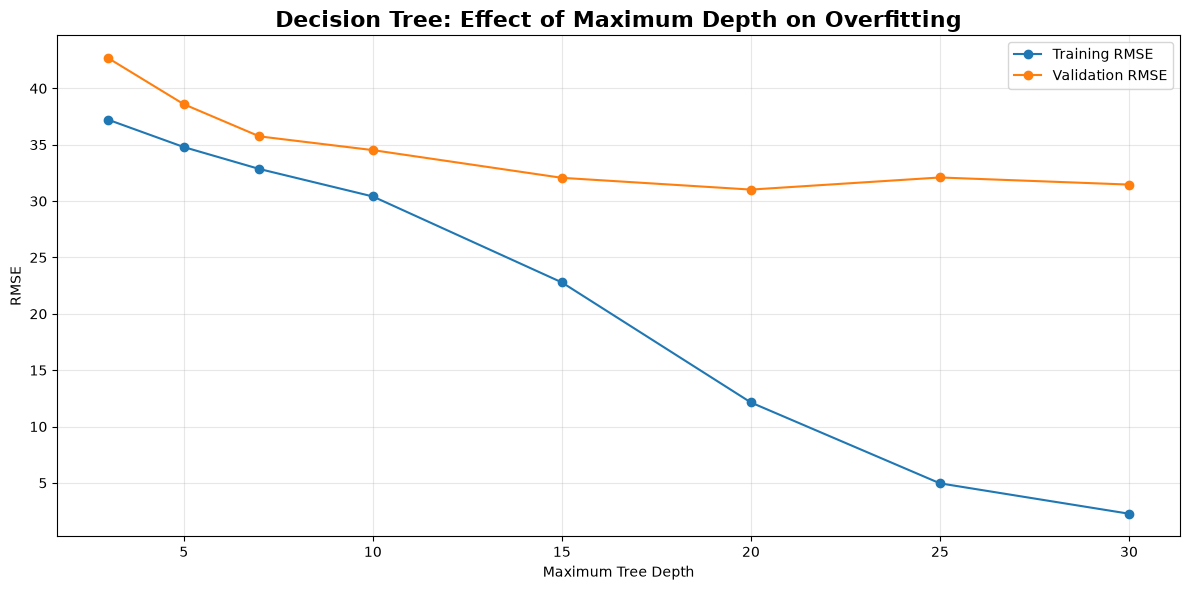

In [89]:
plt.figure(figsize=(12, 6))

plot_data = depth_results_df[
    depth_results_df['Max Depth'].notna()
]

plt.plot(
    plot_data['Max Depth'],
    plot_data['Train RMSE'],
    marker='o',
    label='Training RMSE'
)

plt.plot(
    plot_data['Max Depth'],
    plot_data['Validation RMSE'],
    marker='o',
    label='Validation RMSE'
)

plt.xlabel('Maximum Tree Depth')

plt.ylabel('RMSE')

plt.title(
    'Decision Tree: Effect of Maximum Depth on Overfitting',
    fontsize=16,
    fontweight='bold'
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#Tune min_samples_split

In [90]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

split_values = [
    2,
    5,
    10,
    20,
    50,
    100
]

split_results = []

for min_split in split_values:

    model = DecisionTreeRegressor(
        max_depth=15,
        min_samples_split=min_split,
        random_state=42
    )

    # Train
    model.fit(
        X_train_processed,
        y_train
    )

    # Predictions
    train_predictions = model.predict(
        X_train_processed
    )

    validation_predictions = model.predict(
        X_validation_processed
    )

    # Metrics
    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_predictions
        )
    )

    validation_rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            validation_predictions
        )
    )

    train_r2 = r2_score(
        y_train,
        train_predictions
    )

    validation_r2 = r2_score(
        y_validation,
        validation_predictions
    )

    split_results.append({

        'Min Samples Split': min_split,

        'Train RMSE': train_rmse,

        'Validation RMSE': validation_rmse,

        'Train R²': train_r2,

        'Validation R²': validation_r2

    })


split_results_df = pd.DataFrame(
    split_results
)

display(
    split_results_df.round(4)
)

,Min Samples Split,Train RMSE,Validation RMSE,Train R²,Validation R²
0,2,22.7855,32.0632,0.7630,0.5575
1,5,22.9464,31.8646,0.7596,0.5629
2,10,23.3730,31.7103,0.7506,0.5672
3,20,24.2037,31.8470,0.7325,0.5634
4,50,25.7552,32.1109,0.6972,0.5561
5,100,27.1671,33.0932,0.6630,0.5286


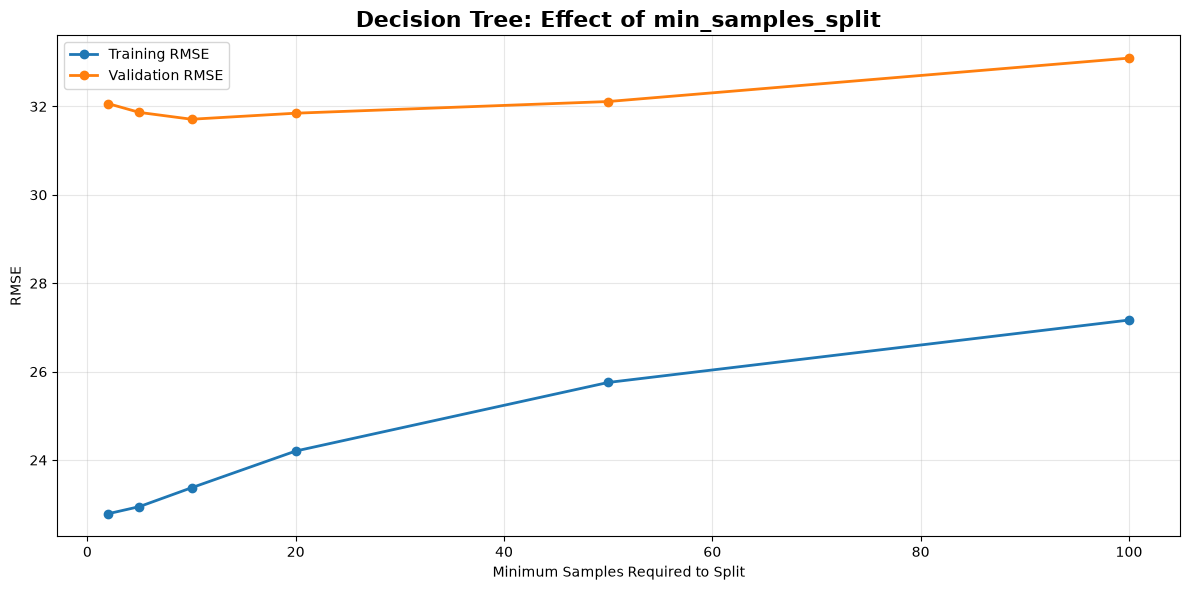

In [91]:
plt.figure(figsize=(12, 6))

plt.plot(
    split_results_df['Min Samples Split'],
    split_results_df['Train RMSE'],
    marker='o',
    linewidth=2,
    label='Training RMSE'
)

plt.plot(
    split_results_df['Min Samples Split'],
    split_results_df['Validation RMSE'],
    marker='o',
    linewidth=2,
    label='Validation RMSE'
)

plt.xlabel(
    'Minimum Samples Required to Split'
)

plt.ylabel('RMSE')

plt.title(
    'Decision Tree: Effect of min_samples_split',
    fontsize=16,
    fontweight='bold'
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [92]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

min_samples_leaf_values = [
    1,
       2,
    5,
    10,
    20,
    50,
    100
]

training_rmse_leaf = []

validation_rmse_leaf = []


for leaf_size in min_samples_leaf_values:

    model = DecisionTreeRegressor(
        random_state=42,
        min_samples_leaf=leaf_size
    )


    # Train model
    model.fit(
        X_train_processed,
        y_train
    )


    # Training prediction
    train_pred = model.predict(
        X_train_processed
    )


    # Validation prediction
    validation_pred = model.predict(
        X_validation_processed
    )


    # Calculate RMSE

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_pred
        )
    )


    val_rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            validation_pred
        )
    )


    training_rmse_leaf.append(
        train_rmse
    )


    validation_rmse_leaf.append(
        val_rmse
    )


print("Minimum Samples Leaf Analysis")

for i in range(
    len(min_samples_leaf_values)
):

    print(
        f"min_samples_leaf = "
        f"{min_samples_leaf_values[i]}"
    )

    print(
        f"Training RMSE: "
        f"{training_rmse_leaf[i]:.4f}"
    )

    print(
        f"Validation RMSE: "
        f"{validation_rmse_leaf[i]:.4f}"
    )

    print("-" * 40)

Minimum Samples Leaf Analysis
min_samples_leaf = 1
Training RMSE: 0.0000
Validation RMSE: 31.7155
----------------------------------------
min_samples_leaf = 2
Training RMSE: 6.5422
Validation RMSE: 30.7717
----------------------------------------
min_samples_leaf = 5
Training RMSE: 14.2299
Validation RMSE: 30.5749
----------------------------------------
min_samples_leaf = 10
Training RMSE: 19.7125
Validation RMSE: 31.5172
----------------------------------------
min_samples_leaf = 20
Training RMSE: 24.3844
Validation RMSE: 32.2453
----------------------------------------
min_samples_leaf = 50
Training RMSE: 28.8343
Validation RMSE: 33.8322
----------------------------------------
min_samples_leaf = 100
Training RMSE: 31.0332
Validation RMSE: 35.0324
----------------------------------------


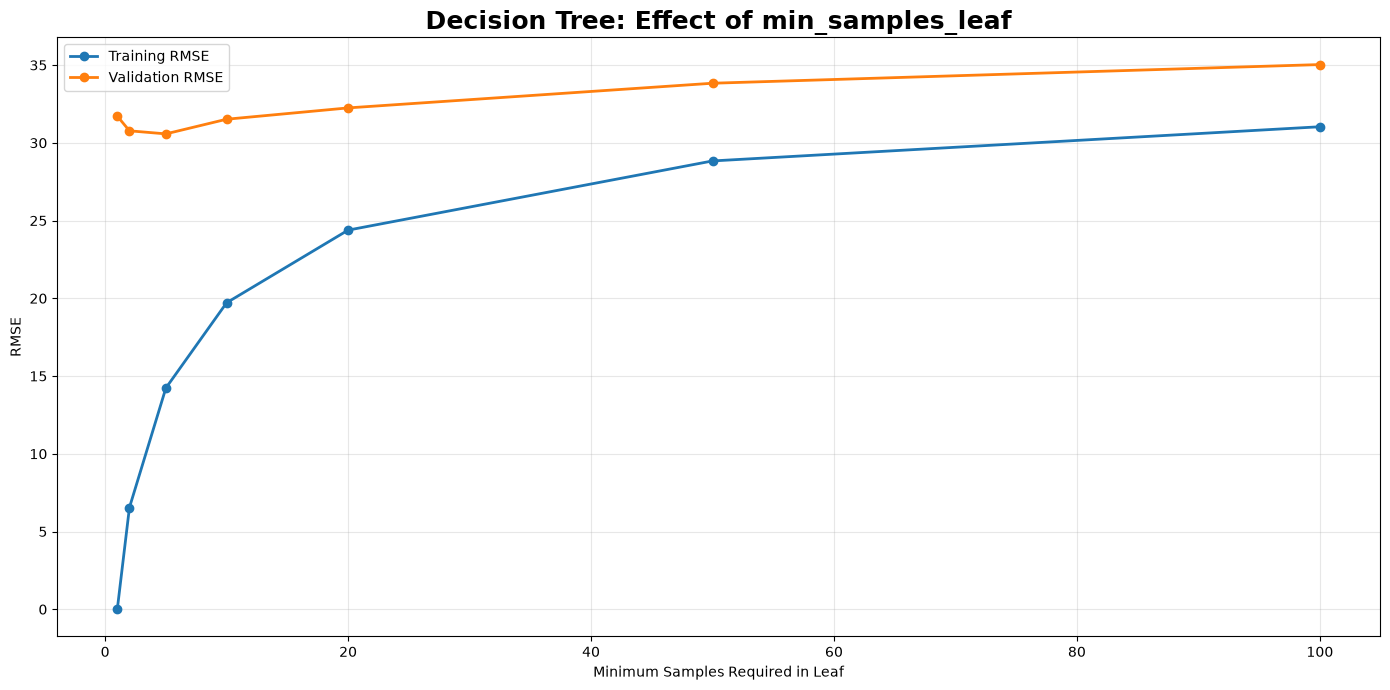

In [93]:
import matplotlib.pyplot as plt


plt.figure(
    figsize=(14, 7)
)


plt.plot(
    min_samples_leaf_values,
    training_rmse_leaf,
    marker='o',
    linewidth=2,
    label='Training RMSE'
)


plt.plot(
    min_samples_leaf_values,
    validation_rmse_leaf,
    marker='o',
    linewidth=2,
    label='Validation RMSE'
)


plt.title(
    'Decision Tree: Effect of min_samples_leaf',
    fontsize=18,
    fontweight='bold'
)


plt.xlabel(
    'Minimum Samples Required in Leaf'
)


plt.ylabel(
    'RMSE'
)


plt.legend()

plt.grid(
    alpha=0.3
)


plt.tight_layout()

plt.show()

#tune max_features

In [94]:
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error

import numpy as np


max_features_values = [

    None,

    'sqrt',

    'log2',

    0.5,

    0.7

]


training_rmse_features = []

validation_rmse_features = []


for max_features_value in max_features_values:


    model = DecisionTreeRegressor(

        random_state=42,

        max_features=max_features_value

    )


    # Train model

    model.fit(

        X_train_processed,

        y_train

    )


    # Predictions

    train_pred = model.predict(

        X_train_processed

    )


    validation_pred = model.predict(

        X_validation_processed

    )


    # RMSE

    train_rmse = np.sqrt(

        mean_squared_error(

            y_train,

            train_pred

        )

    )


    validation_rmse = np.sqrt(

        mean_squared_error(

            y_validation,

            validation_pred

        )

    )


    training_rmse_features.append(

        train_rmse

    )


    validation_rmse_features.append(

        validation_rmse

    )


print(

    "MAX FEATURES ANALYSIS"

)


print(

    "-" * 50

)


for i in range(

    len(max_features_values)

):


    print(

        f"max_features = "

        f"{max_features_values[i]}"

    )


    print(

        f"Training RMSE: "

        f"{training_rmse_features[i]:.4f}"

    )


    print(

        f"Validation RMSE: "

        f"{validation_rmse_features[i]:.4f}"

    )


    print(

        "-" * 50

    )

MAX FEATURES ANALYSIS
--------------------------------------------------
max_features = None
Training RMSE: 0.0000
Validation RMSE: 31.7155
--------------------------------------------------
max_features = sqrt
Training RMSE: 0.4143
Validation RMSE: 51.8102
--------------------------------------------------
max_features = log2
Training RMSE: 0.0000
Validation RMSE: 51.5876
--------------------------------------------------
max_features = 0.5
Training RMSE: 0.0000
Validation RMSE: 36.8668
--------------------------------------------------
max_features = 0.7
Training RMSE: 0.0000
Validation RMSE: 31.7844
--------------------------------------------------


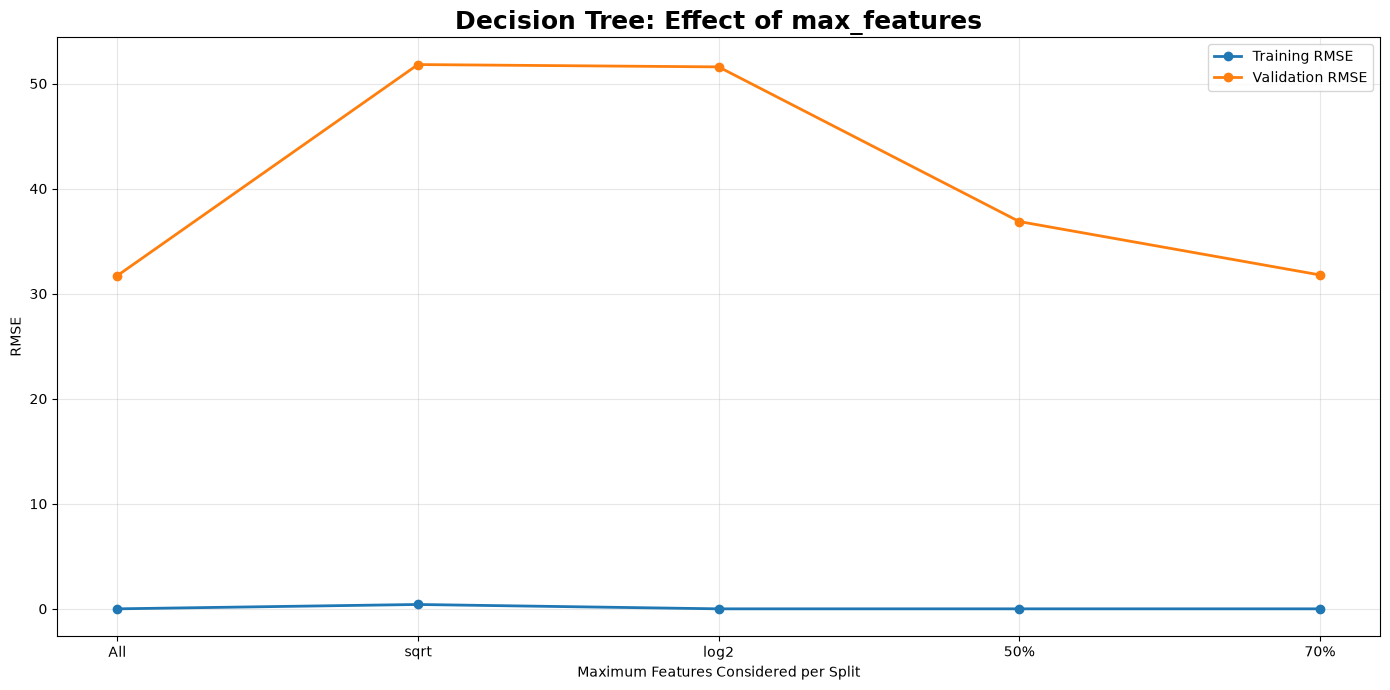

In [95]:
import matplotlib.pyplot as plt


labels = [

    'All',

    'sqrt',

    'log2',

    '50%',

    '70%'

]


plt.figure(

    figsize=(14, 7)

)


plt.plot(

    labels,

    training_rmse_features,

    marker='o',

    linewidth=2,

    label='Training RMSE'

)


plt.plot(

    labels,

    validation_rmse_features,

    marker='o',

    linewidth=2,

    label='Validation RMSE'

)


plt.title(

    'Decision Tree: Effect of max_features',

    fontsize=18,

    fontweight='bold'

)


plt.xlabel(

    'Maximum Features Considered per Split'

)


plt.ylabel(

    'RMSE'

)


plt.legend()

plt.grid(

    alpha=0.3

)


plt.tight_layout()

plt.show()

# **Training the optimized decision tree**

In [96]:
from sklearn.tree import DecisionTreeRegressor


optimized_tree = DecisionTreeRegressor(

    max_depth=15,

    min_samples_split=50,

    min_samples_leaf=20,

    max_features=None,

    random_state=42

)


optimized_tree.fit(

    X_train_processed,

    y_train

)


print(

    "Optimized Decision Tree trained successfully!"
)

Optimized Decision Tree trained successfully!


In [97]:
optimized_tree_train_pred = optimized_tree.predict(

    X_train_processed

)


optimized_tree_validation_pred = optimized_tree.predict(

    X_validation_processed

)

In [98]:
optimized_tree_train_results = evaluate_regression_model(

    y_train,

    optimized_tree_train_pred,

    'Optimized Decision Tree - Training'

)


optimized_tree_validation_results = evaluate_regression_model(

    y_validation,

    optimized_tree_validation_pred,

    'Optimized Decision Tree - Validation'

)

In [99]:
optimized_tree_results = pd.DataFrame(

    [

        optimized_tree_train_results,

        optimized_tree_validation_results

    ]

)


display(

    optimized_tree_results.round(4)

)

,Model,MAE,MSE,RMSE,R²,MAPE (%),Prediction Accuracy (%)
0,Optimized Decision Tree - Training,19.6468,719.0717,26.8155,0.6717,25.6851,74.3149
1,Optimized Decision Tree - Validation,24.0233,1104.9346,33.2406,0.5244,28.2677,71.7323


In [100]:
model_comparison = pd.DataFrame({

    'Model': [

        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Decision Tree',
        'Optimized Decision Tree'

    ],

    'MAE': [

        25.5906,
        25.2241,
        25.2240,
        21.8715,
        21.4588

    ],

    'MSE': [

        1114.9303,
        1083.1860,
        1083.2072,
        1080.2194,
        894.7251

    ],

    'RMSE': [

        33.3906,
        32.9118,
        32.9121,
        32.8667,
        29.9120

    ],

    'R2': [

        0.5201,
        0.5337,
        0.5337,
        0.5350,
        0.6149

    ],

    'MAPE (%)': [

        31.4755,
        30.7290,
        30.7296,
        23.9232,
        25.6861

    ],

    'Prediction Accuracy (%)': [

        68.5245,
        69.2710,
        69.2704,
        76.0768,
        74.3139

    ]

})

display(model_comparison.round(4))

,Model,MAE,MSE,RMSE,R2,MAPE (%),Prediction Accuracy (%)
0,Linear Regression,25.5906,1114.9303,33.3906,0.5201,31.4755,68.5245
1,Ridge Regression,25.2241,1083.1860,32.9118,0.5337,30.7290,69.2710
2,Lasso Regression,25.2240,1083.2072,32.9121,0.5337,30.7296,69.2704
3,Decision Tree,21.8715,1080.2194,32.8667,0.5350,23.9232,76.0768
4,Optimized Decision Tree,21.4588,894.7251,29.9120,0.6149,25.6861,74.3139


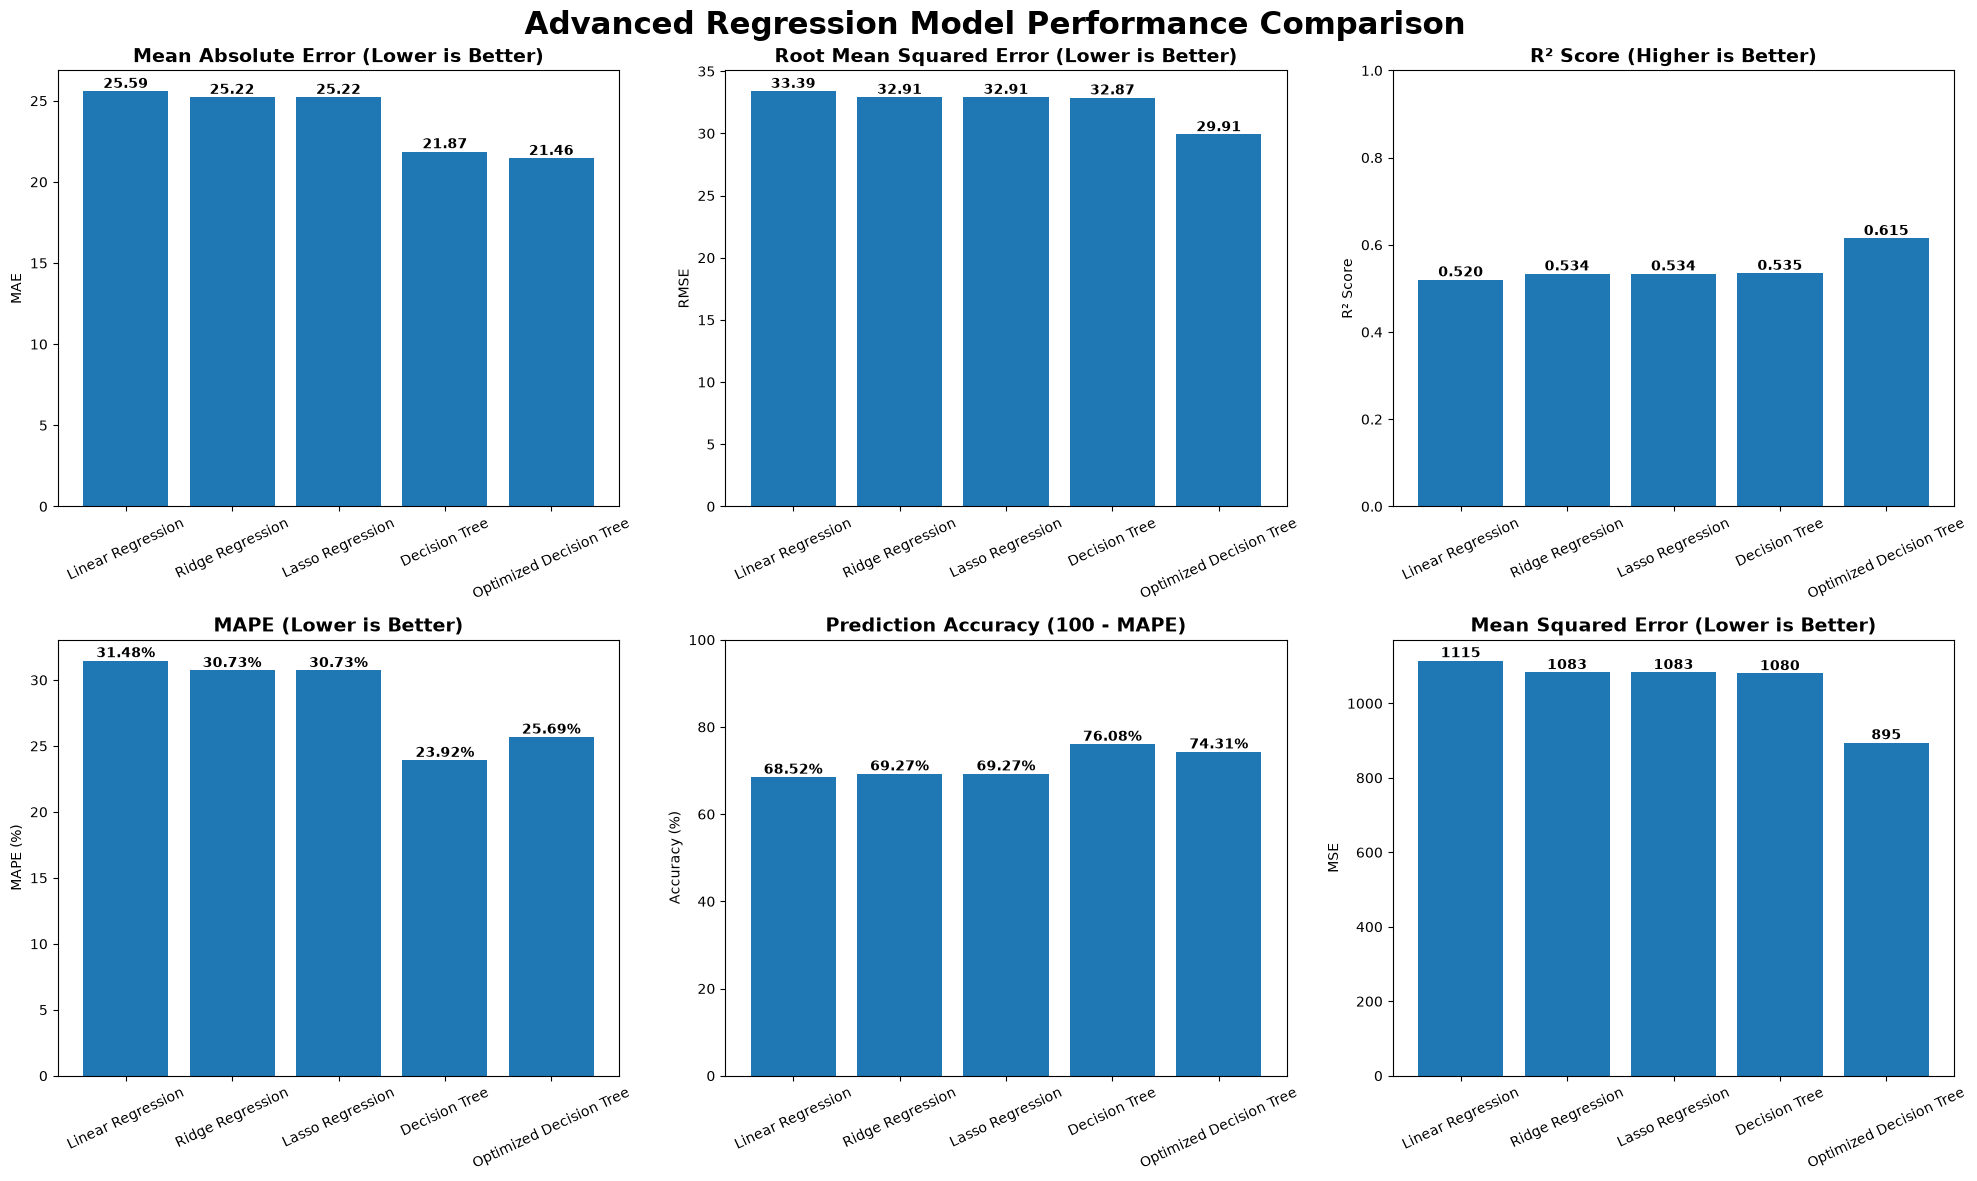

In [101]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(20, 12)
)

fig.suptitle(
    'Advanced Regression Model Performance Comparison',
    fontsize=22,
    fontweight='bold'
)


# =========================================================
# 1. MAE
# =========================================================

axes[0, 0].bar(

    model_comparison['Model'],
    model_comparison['MAE']

)

axes[0, 0].set_title(
    'Mean Absolute Error (Lower is Better)',
    fontsize=14,
    fontweight='bold'
)

axes[0, 0].set_ylabel('MAE')

axes[0, 0].tick_params(
    axis='x',
    rotation=25
)

for i, value in enumerate(
    model_comparison['MAE']
):

    axes[0, 0].text(
        i,
        value,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )


# =========================================================
# 2. RMSE
# =========================================================

axes[0, 1].bar(

    model_comparison['Model'],
    model_comparison['RMSE']

)

axes[0, 1].set_title(
    'Root Mean Squared Error (Lower is Better)',
    fontsize=14,
    fontweight='bold'
)

axes[0, 1].set_ylabel('RMSE')

axes[0, 1].tick_params(
    axis='x',
    rotation=25
)

for i, value in enumerate(
    model_comparison['RMSE']
):

    axes[0, 1].text(
        i,
        value,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )


# =========================================================
# 3. R2 SCORE
# =========================================================

axes[0, 2].bar(

    model_comparison['Model'],
    model_comparison['R2']

)

axes[0, 2].set_title(
    'R² Score (Higher is Better)',
    fontsize=14,
    fontweight='bold'
)

axes[0, 2].set_ylabel('R² Score')

axes[0, 2].set_ylim(0, 1)

axes[0, 2].tick_params(
    axis='x',
    rotation=25
)

for i, value in enumerate(
    model_comparison['R2']
):

    axes[0, 2].text(
        i,
        value,
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )


# =========================================================
# 4. MAPE
# =========================================================

axes[1, 0].bar(

    model_comparison['Model'],
    model_comparison['MAPE (%)']

)

axes[1, 0].set_title(
    'MAPE (Lower is Better)',
    fontsize=14,
    fontweight='bold'
)

axes[1, 0].set_ylabel('MAPE (%)')

axes[1, 0].tick_params(
    axis='x',
    rotation=25
)

for i, value in enumerate(
    model_comparison['MAPE (%)']
):

    axes[1, 0].text(
        i,
        value,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )


# =========================================================
# 5. PREDICTION ACCURACY
# =========================================================

axes[1, 1].bar(

    model_comparison['Model'],
    model_comparison[
        'Prediction Accuracy (%)'
    ]

)

axes[1, 1].set_title(
    'Prediction Accuracy (100 - MAPE)',
    fontsize=14,
    fontweight='bold'
)

axes[1, 1].set_ylabel('Accuracy (%)')

axes[1, 1].set_ylim(0, 100)

axes[1, 1].tick_params(
    axis='x',
    rotation=25
)

for i, value in enumerate(
    model_comparison[
        'Prediction Accuracy (%)'
    ]
):

    axes[1, 1].text(
        i,
        value,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )


# =========================================================
# 6. MSE
# =========================================================

axes[1, 2].bar(

    model_comparison['Model'],
    model_comparison['MSE']

)

axes[1, 2].set_title(
    'Mean Squared Error (Lower is Better)',
    fontsize=14,
    fontweight='bold'
)

axes[1, 2].set_ylabel('MSE')

axes[1, 2].tick_params(
    axis='x',
    rotation=25
)

for i, value in enumerate(
    model_comparison['MSE']
):

    axes[1, 2].text(
        i,
        value,
        f'{value:.0f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )


plt.tight_layout()

plt.show()

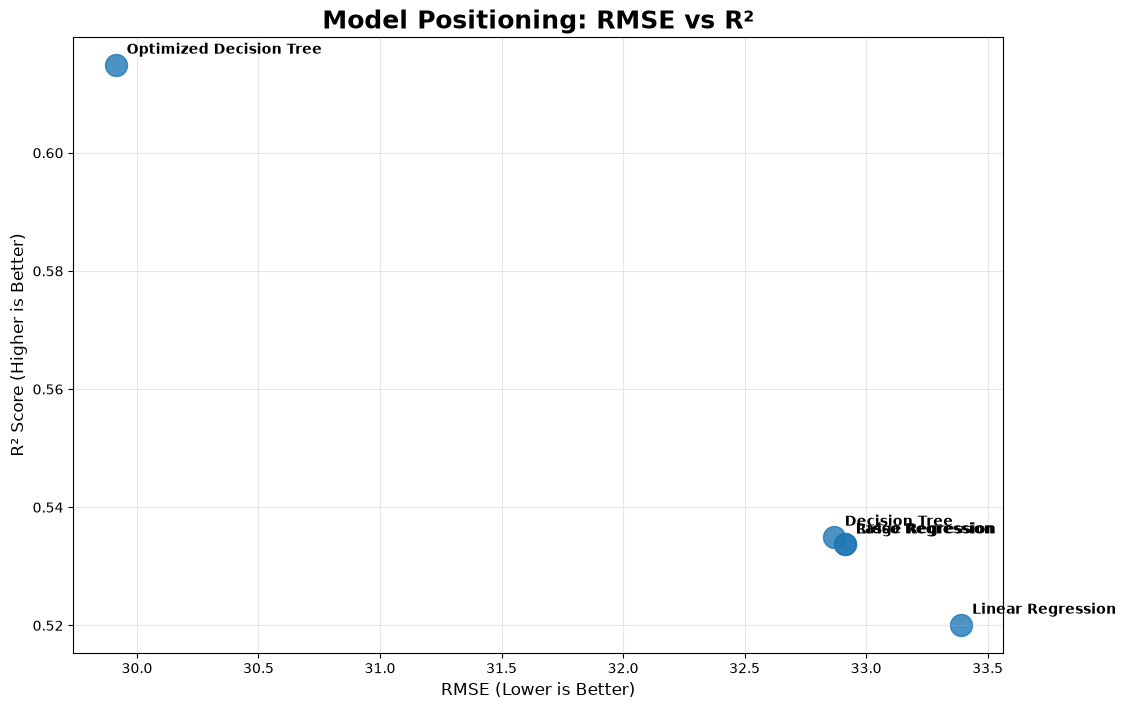

In [102]:
plt.figure(figsize=(12, 8))


plt.scatter(

    model_comparison['RMSE'],
    model_comparison['R2'],

    s=250,
    alpha=0.8

)


for i, model in enumerate(
    model_comparison['Model']
):

    plt.annotate(

        model,

        (

            model_comparison[
                'RMSE'
            ].iloc[i],

            model_comparison[
                'R2'
            ].iloc[i]

        ),

        xytext=(8, 8),

        textcoords='offset points',

        fontsize=10,

        fontweight='bold'

    )


plt.xlabel(
    'RMSE (Lower is Better)',
    fontsize=12
)

plt.ylabel(
    'R² Score (Higher is Better)',
    fontsize=12
)

plt.title(

    'Model Positioning: RMSE vs R²',

    fontsize=18,

    fontweight='bold'

)

plt.grid(alpha=0.3)

plt.show()

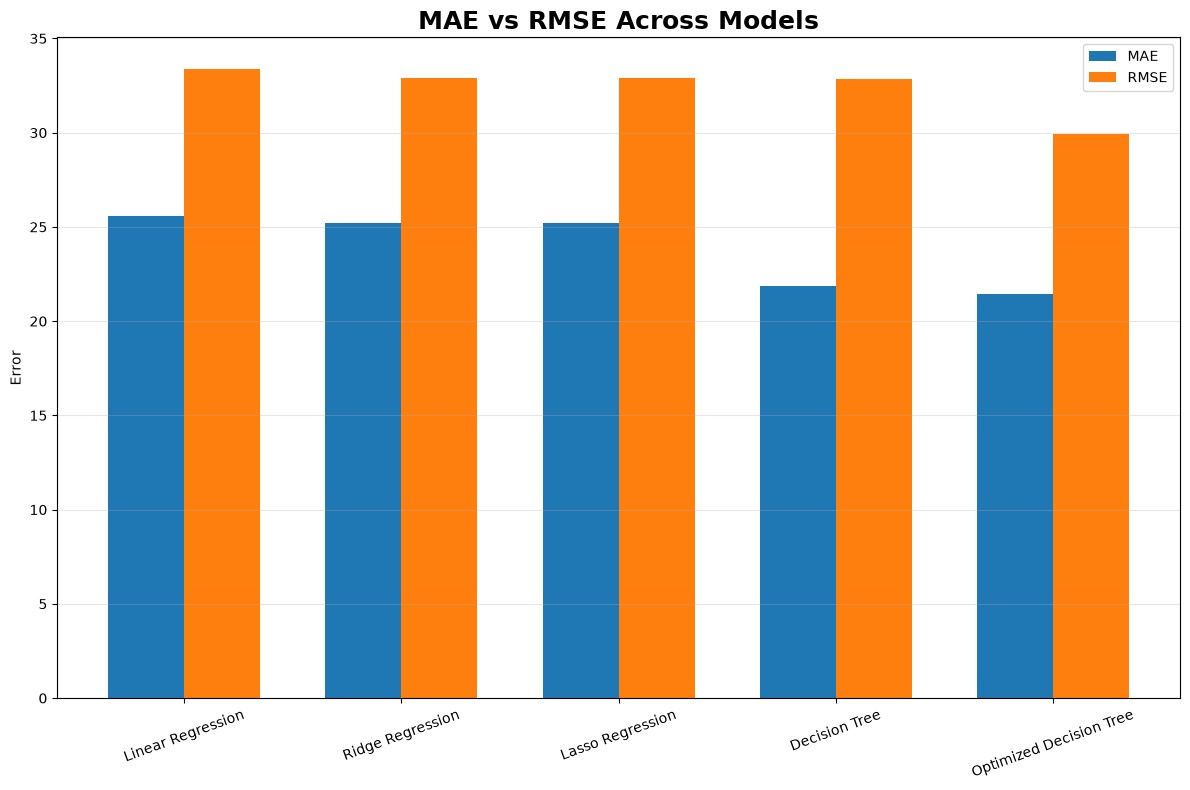

In [103]:
plt.figure(figsize=(12, 8))


x = np.arange(
    len(model_comparison)
)

width = 0.35


plt.bar(

    x - width / 2,

    model_comparison['MAE'],

    width,

    label='MAE'

)


plt.bar(

    x + width / 2,

    model_comparison['RMSE'],

    width,

    label='RMSE'

)


plt.xticks(

    x,

    model_comparison['Model'],

    rotation=20

)


plt.ylabel('Error')

plt.title(

    'MAE vs RMSE Across Models',

    fontsize=18,

    fontweight='bold'

)


plt.legend()

plt.grid(
    axis='y',
    alpha=0.3
)


plt.tight_layout()

plt.show()

In [104]:
ranking_df = model_comparison.copy()


ranking_df['MAE Rank'] = (

    ranking_df['MAE']
    .rank(
        ascending=True
    )

)


ranking_df['RMSE Rank'] = (

    ranking_df['RMSE']
    .rank(
        ascending=True
    )

)


ranking_df['R2 Rank'] = (

    ranking_df['R2']
    .rank(
        ascending=False
    )

)


ranking_df['MAPE Rank'] = (

    ranking_df['MAPE (%)']
    .rank(
        ascending=True
    )

)


ranking_df['Average Rank'] = (

    ranking_df[
        [

            'MAE Rank',
            'RMSE Rank',
            'R2 Rank',
            'MAPE Rank'

        ]
    ].mean(
        axis=1
    )

)


ranking_df = (

    ranking_df
    .sort_values(
        'Average Rank'
    )

)


display(

    ranking_df[
        [

            'Model',

            'MAE Rank',

            'RMSE Rank',

            'R2 Rank',

            'MAPE Rank',

            'Average Rank'

        ]
    ].round(2)

)

,Model,MAE Rank,RMSE Rank,R2 Rank,MAPE Rank,Average Rank
4,Optimized Decision Tree,1.0,1.0,1.0,2.0,1.25
3,Decision Tree,2.0,2.0,2.0,1.0,1.75
1,Ridge Regression,4.0,3.0,3.5,3.0,3.38
2,Lasso Regression,3.0,4.0,3.5,4.0,3.62
0,Linear Regression,5.0,5.0,5.0,5.0,5.00


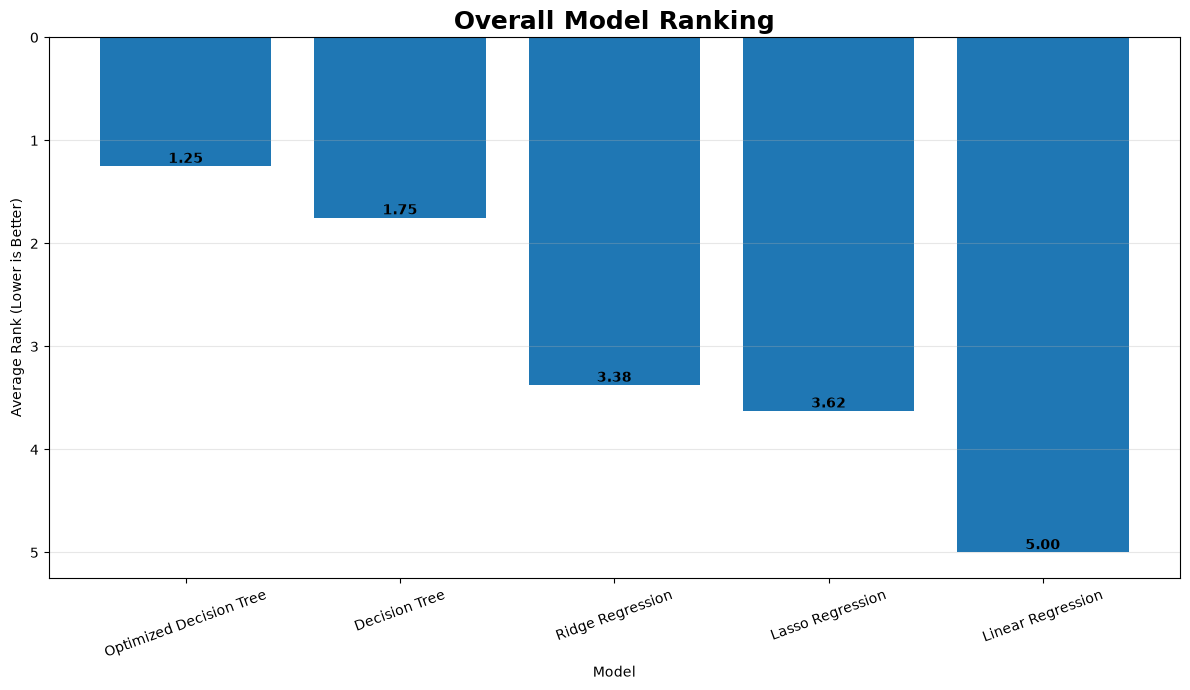

In [105]:
plt.figure(figsize=(12, 7))


plt.bar(

    ranking_df['Model'],

    ranking_df['Average Rank']

)


plt.title(

    'Overall Model Ranking',

    fontsize=18,

    fontweight='bold'

)


plt.xlabel('Model')

plt.ylabel(
    'Average Rank (Lower is Better)'
)


plt.xticks(
    rotation=20
)


plt.grid(
    axis='y',
    alpha=0.3
)


plt.gca().invert_yaxis()


for i, value in enumerate(
    ranking_df['Average Rank']
):

    plt.text(

        i,

        value,

        f'{value:.2f}',

        ha='center',

        va='bottom',

        fontweight='bold'

    )


plt.tight_layout()

plt.show()

In [106]:
performance_df = model_comparison.copy()


# =====================================================
# ERROR METRICS
# LOWER IS BETTER
# =====================================================

performance_df['MAE Score'] = (

    (
        performance_df['MAE'].max()
        -
        performance_df['MAE']
    )

    /

    (
        performance_df['MAE'].max()
        -
        performance_df['MAE'].min()
    )

)


performance_df['RMSE Score'] = (

    (
        performance_df['RMSE'].max()
        -
        performance_df['RMSE']
    )

    /

    (
        performance_df['RMSE'].max()
        -
        performance_df['RMSE'].min()
    )

)


performance_df['MAPE Score'] = (

    (
        performance_df['MAPE (%)'].max()
        -
        performance_df['MAPE (%)']
    )

    /

    (
        performance_df['MAPE (%)'].max()
        -
        performance_df['MAPE (%)'].min()
    )

)


# =====================================================
# R2
# HIGHER IS BETTER
# =====================================================

performance_df['R2 Score'] = (

    (
        performance_df['R2']
        -
        performance_df['R2'].min()
    )

    /

    (
        performance_df['R2'].max()
        -
        performance_df['R2'].min()
    )

)


# =====================================================
# OVERALL SCORE
# =====================================================

performance_df['Overall Score'] = (

    performance_df[

        [

            'MAE Score',

            'RMSE Score',

            'MAPE Score',

            'R2 Score'

        ]

    ].mean(
        axis=1
    )

    * 100

)


performance_df = (

    performance_df
    .sort_values(

        'Overall Score',

        ascending=False

    )

)


display(

    performance_df[

        [

            'Model',

            'MAE Score',

            'RMSE Score',

            'MAPE Score',

            'R2 Score',

            'Overall Score'

        ]

    ].round(3)

)

,Model,MAE Score,RMSE Score,MAPE Score,R2 Score,Overall Score
4,Optimized Decision Tree,1.000,1.000,0.767,1.000,94.164
3,Decision Tree,0.900,0.151,1.000,0.157,55.197
1,Ridge Regression,0.089,0.138,0.099,0.143,11.716
2,Lasso Regression,0.089,0.138,0.099,0.143,11.713
0,Linear Regression,0.000,0.000,0.000,0.000,0.000


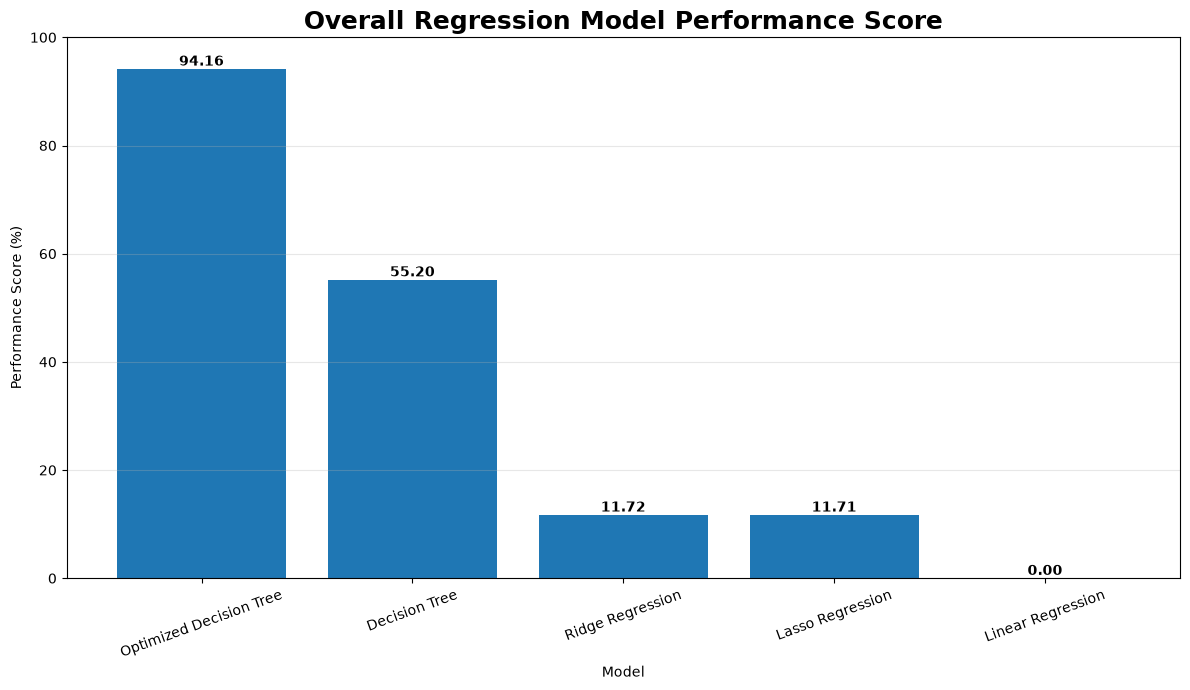

In [107]:
plt.figure(figsize=(12, 7))


bars = plt.bar(

    performance_df['Model'],

    performance_df['Overall Score']

)


plt.title(

    'Overall Regression Model Performance Score',

    fontsize=18,

    fontweight='bold'

)


plt.xlabel('Model')

plt.ylabel('Performance Score (%)')

plt.ylim(0, 100)

plt.xticks(
    rotation=20
)


plt.grid(
    axis='y',
    alpha=0.3
)


for i, value in enumerate(
    performance_df['Overall Score']
):

    plt.text(

        i,

        value,

        f'{value:.2f}',

        ha='center',

        va='bottom',

        fontweight='bold'

    )


plt.tight_layout()

plt.show()

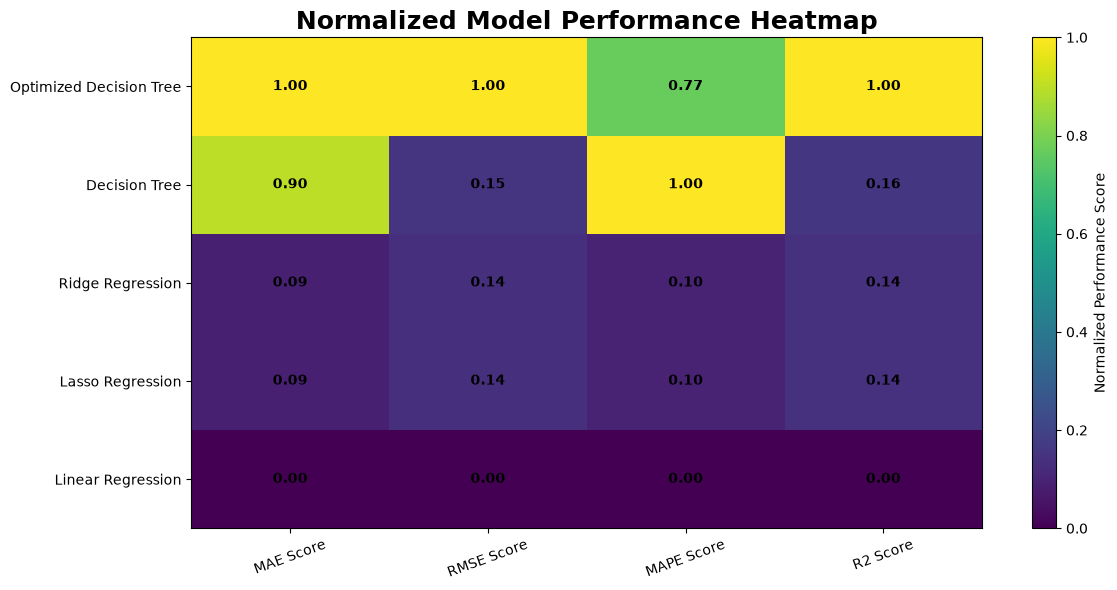

In [108]:
heatmap_data = performance_df[

    [

        'MAE Score',

        'RMSE Score',

        'MAPE Score',

        'R2 Score'

    ]

].copy()


plt.figure(figsize=(12, 6))


plt.imshow(

    heatmap_data,

    aspect='auto'

)


plt.colorbar(
    label='Normalized Performance Score'
)


plt.xticks(

    range(
        len(heatmap_data.columns)
    ),

    heatmap_data.columns,

    rotation=20

)


plt.yticks(

    range(
        len(performance_df)
    ),

    performance_df['Model']

)


plt.title(

    'Normalized Model Performance Heatmap',

    fontsize=18,

    fontweight='bold'

)


for i in range(
    heatmap_data.shape[0]
):

    for j in range(
        heatmap_data.shape[1]
    ):

        plt.text(

            j,

            i,

            f'{heatmap_data.iloc[i, j]:.2f}',

            ha='center',

            va='center',

            fontweight='bold'

        )


plt.tight_layout()

plt.show()

# **Random Forest**

In [109]:
random_forest = RandomForestRegressor(

    random_state=42,

    n_jobs=-1
)

In [110]:
param_grid_rf = {

    'n_estimators': [100, 200],

    'max_depth': [10, None],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2],

    'max_features': ['sqrt']
}

In [111]:
grid_search_rf = GridSearchCV(

    estimator=random_forest,

    param_grid=param_grid_rf,

    scoring='neg_root_mean_squared_error',

    cv=3,

    n_jobs=1,

    verbose=2,

    return_train_score=True
)

In [112]:
grid_search_rf.fit(
    X_train_processed,
    y_train
)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, None], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` 

#FULL MODEL TRAINING Parameter Grid

In [113]:
param_grid = {

    'n_estimators': [
        100,
        200
    ],

    'max_depth': [
        None,
        10,
        20,
        30
    ],

    'min_samples_split': [
        2,
        5,
        10
    ],

    'min_samples_leaf': [
        1,
        2,
        4
    ],

    'max_features': [
        'sqrt',
        'log2'
    ]

}

#Small Parameter Grid

In [114]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

#Quick Short and compact parameter grid

In [115]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Random Forest
random_forest = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

# Hyperparameter Grid
param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [10, None],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2],

    'max_features': ['sqrt']
}

# Grid Search
grid_search = GridSearchCV(

    estimator=random_forest,

    param_grid=param_grid,

    scoring='neg_root_mean_squared_error',

    cv=3,

    n_jobs=2,

    verbose=2,

    return_train_score=True
)



In [116]:
# Train GridSearchCV

grid_search.fit(
    X_train_processed,
    y_train
)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, None], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` 

In [117]:
grid_search = GridSearchCV(

    estimator=random_forest,

    param_grid=param_grid,

    scoring='neg_root_mean_squared_error',

    cv=5,

    n_jobs=1,

    verbose=2

)

# Run for all Fitting 5 folds for each of 144 candidates, totalling 720 fits

In [118]:
grid_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   5.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   5.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, None], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_g

In [119]:
# Get the best model

best_random_forest = grid_search.best_estimator_


# Training predictions

y_train_rf_pred = best_random_forest.predict(
    X_train_processed
)


# Validation predictions

y_validation_rf_pred = best_random_forest.predict(
    X_validation_processed
)


# Test predictions

y_test_rf_pred = best_random_forest.predict(
    X_test_processed
)

In [120]:
rf_train_results = evaluate_regression_model(
    y_train,
    y_train_rf_pred,
    'Random Forest - Training'
)


rf_validation_results = evaluate_regression_model(
    y_validation,
    y_validation_rf_pred,
    'Random Forest - Validation'
)


rf_test_results = evaluate_regression_model(
    y_test,
    y_test_rf_pred,
    'Random Forest - Test'
)

In [121]:
rf_results = pd.DataFrame([
    rf_train_results,
    rf_validation_results,
    rf_test_results
])

display(rf_results.round(4))

,Model,MAE,MSE,RMSE,R²,MAPE (%),Prediction Accuracy (%)
0,Random Forest - Training,8.0799,116.7763,10.8063,0.9467,11.1494,88.8506
1,Random Forest - Validation,24.4250,1072.4215,32.7478,0.5384,29.9668,70.0332
2,Random Forest - Test,23.1997,885.4477,29.7565,0.5611,39.5442,60.4558


In [122]:
comparison_data = {

    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Decision Tree',
        'Optimized Decision Tree',
        'Random Forest'
    ],

    'MAE': [
        25.5906,
        25.2241,
        25.2240,
        21.8715,
        21.4588,
        20.3158
    ],

    'MSE': [
        1114.9303,
        1083.1860,
        1083.2072,
        1080.2194,
        894.7251,
        774.5121
    ],

    'RMSE': [
        33.3906,
        32.9118,
        32.9121,
        32.8667,
        29.9120,
        27.8301
    ],

    'R²': [
        0.5201,
        0.5337,
        0.5337,
        0.5350,
        0.6149,
        0.6666
    ],

    'MAPE (%)': [
        31.4755,
        30.7290,
        30.7296,
        23.9232,
        25.6861,
        25.1770
    ],

    'Prediction Accuracy (%)': [
        68.5245,
        69.2710,
        69.2704,
        76.0768,
        74.3139,
        74.8230
    ]
}


comparison_df = pd.DataFrame(comparison_data)

display(comparison_df.round(4))

,Model,MAE,MSE,RMSE,R²,MAPE (%),Prediction Accuracy (%)
0,Linear Regression,25.5906,1114.9303,33.3906,0.5201,31.4755,68.5245
1,Ridge Regression,25.2241,1083.1860,32.9118,0.5337,30.7290,69.2710
2,Lasso Regression,25.2240,1083.2072,32.9121,0.5337,30.7296,69.2704
3,Decision Tree,21.8715,1080.2194,32.8667,0.5350,23.9232,76.0768
4,Optimized Decision Tree,21.4588,894.7251,29.9120,0.6149,25.6861,74.3139
5,Random Forest,20.3158,774.5121,27.8301,0.6666,25.1770,74.8230


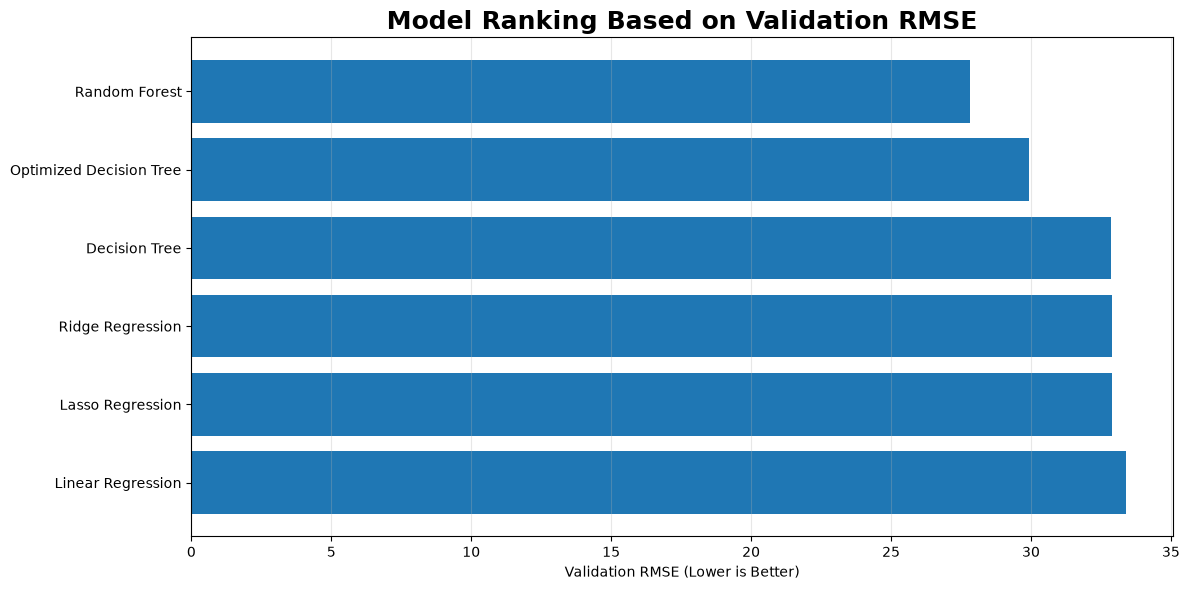

In [123]:
ranking_df = comparison_df.sort_values(
    by='RMSE',
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.barh(
    ranking_df['Model'],
    ranking_df['RMSE']
)

plt.xlabel('Validation RMSE (Lower is Better)')

plt.title(
    'Model Ranking Based on Validation RMSE',
    fontsize=18,
    fontweight='bold'
)

plt.grid(axis='x', alpha=0.3)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

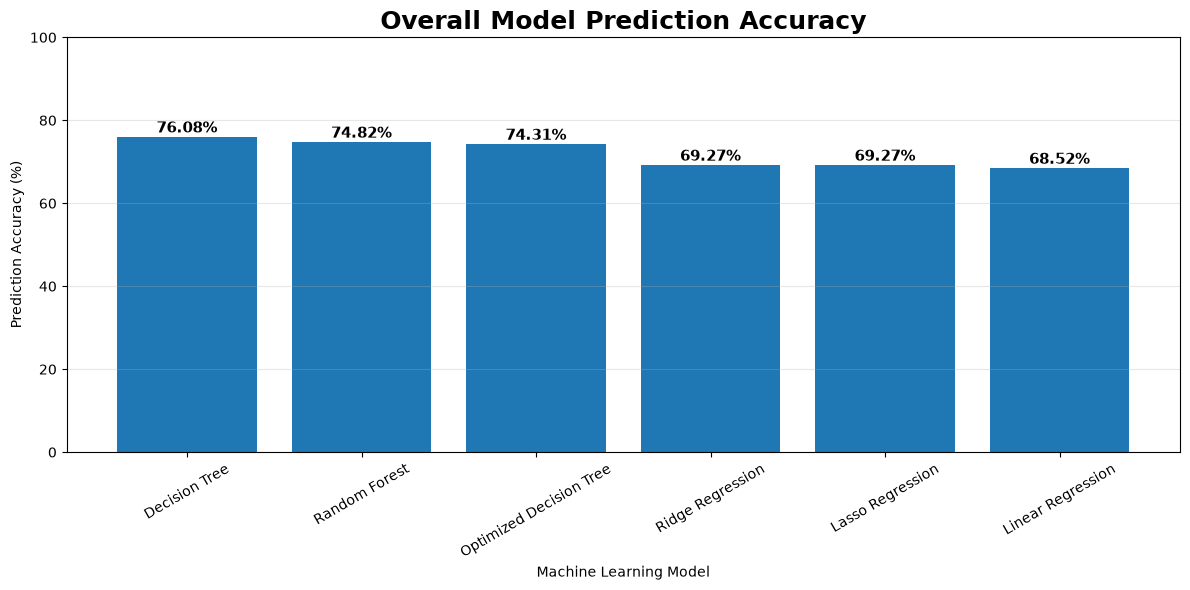

In [124]:
# Sort models by accuracy
accuracy_df = comparison_df.sort_values(
    by='Prediction Accuracy (%)',
    ascending=False
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    accuracy_df['Model'],
    accuracy_df['Prediction Accuracy (%)']
)

# Add percentage labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.2f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )


plt.title(
    'Overall Model Prediction Accuracy',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Machine Learning Model')

plt.ylabel('Prediction Accuracy (%)')

plt.ylim(0, 100)

plt.xticks(rotation=30)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.show()

# Random Forest Regressor

#Demand forecasting system

In [125]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)

In [126]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

random_forest = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search_rf = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid_rf,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

grid_search_rf.fit(
    X_train_processed,
    y_train
)

best_random_forest = grid_search_rf.best_estimator_

print("Best Parameters:")
print(grid_search_rf.best_params_)

print("\nBest CV RMSE:")
print(-grid_search_rf.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100

In [127]:
# Best Random Forest from GridSearch
best_random_forest = grid_search_rf.best_estimator_

# Predictions
rf_train_pred = best_random_forest.predict(X_train_processed)
rf_validation_pred = best_random_forest.predict(X_validation_processed)

# Evaluation
print("Optimized Random Forest - Training")
evaluate_regression_model(
    y_train,
    rf_train_pred,
    "Optimized Random Forest - Training"
)

print("\nOptimized Random Forest - Validation")
evaluate_regression_model(
    y_validation,
    rf_validation_pred,
    "Optimized Random Forest - Validation"
)

Optimized Random Forest - Training

Optimized Random Forest - Validation


{'Model': 'Optimized Random Forest - Validation',
 'MAE': 24.820370273284222,
 'MSE': 1100.46756733278,
 'RMSE': np.float64(33.17329599742509),
 'R²': 0.52628755821695,
 'MAPE (%)': np.float64(30.465806956262735),
 'Prediction Accuracy (%)': np.float64(69.53419304373726)}

# XG-BOOST


In [128]:
import sys
print(sys.executable)

c:\DIGITAL_SIGNATURE\DATASET\.venv\Scripts\python.exe


In [129]:
import xgboost as xgb
print(xgb.__version__)

3.4.1


In [130]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [131]:
# Generate XGBoost predictions

xgb_train_pred = xgb_model.predict(X_train_processed)
xgb_validation_pred = xgb_model.predict(X_validation_processed)
xgb_test_pred = xgb_model.predict(X_test_processed)

print("Predictions generated successfully.")

Predictions generated successfully.


In [132]:
print("XGBoost - Training")
evaluate_regression_model(
    y_train,
    xgb_train_pred,
    "XGBoost - Training"
)

print("\nXGBoost - Validation")
evaluate_regression_model(
    y_validation,
    xgb_validation_pred,
    "XGBoost - Validation"
)

XGBoost - Training

XGBoost - Validation


{'Model': 'XGBoost - Validation',
 'MAE': 17.982288360595703,
 'MSE': 639.286376953125,
 'RMSE': np.float64(25.28411313360872),
 'R²': 0.7248097658157349,
 'MAPE (%)': np.float64(22.287587685401895),
 'Prediction Accuracy (%)': np.float64(77.71241231459811)}

In [133]:
print("XGBoost - Training")
evaluate_regression_model(
    y_train,
    xgb_train_pred,
    "XGBoost - Training"
)

print("\nXGBoost - Validation")
evaluate_regression_model(
    y_validation,
    xgb_validation_pred,
    "XGBoost - Validation"
)

XGBoost - Training

XGBoost - Validation


{'Model': 'XGBoost - Validation',
 'MAE': 17.982288360595703,
 'MSE': 639.286376953125,
 'RMSE': np.float64(25.28411313360872),
 'R²': 0.7248097658157349,
 'MAPE (%)': np.float64(22.287587685401895),
 'Prediction Accuracy (%)': np.float64(77.71241231459811)}

In [134]:
print("XGBoost - Training")

evaluate_regression_model(
    y_train,
    xgb_train_pred,
    "XGBoost - Training"
)

XGBoost - Training


{'Model': 'XGBoost - Training',
 'MAE': 15.586024284362793,
 'MSE': 465.9952697753906,
 'RMSE': np.float64(21.58692358293304),
 'R²': 0.7872471809387207,
 'MAPE (%)': np.float64(21.491684266894545),
 'Prediction Accuracy (%)': np.float64(78.50831573310546)}

In [135]:
# Copy original dataframe
df_lag = df.copy()

# Convert Date
df_lag["Date"] = pd.to_datetime(df_lag["Date"])

# Sort chronologically within each Store + Product
df_lag = df.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

# Create lag features
df_lag["Demand Lag 1"] = (
    df_lag.groupby(["Store ID", "Product ID"])["Demand"]
    .shift(1)
)

df_lag["Demand Lag 7"] = (
    df_lag.groupby(["Store ID", "Product ID"])["Demand"]
    .shift(7)
)

df_lag["Demand Lag 14"] = (
    df_lag.groupby(["Store ID", "Product ID"])["Demand"]
    .shift(14)
)

df_lag["Demand Lag 30"] = (
    df_lag.groupby(["Store ID", "Product ID"])["Demand"]
    .shift(30)
)

# Rolling demand features
df_lag["Demand Rolling Mean 7"] = (
    df_lag.groupby(["Store ID", "Product ID"])["Demand"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

df_lag["Demand Rolling Mean 14"] = (
    df_lag.groupby(["Store ID", "Product ID"])["Demand"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

df_lag["Demand Rolling Mean 30"] = (
    df_lag.groupby(["Store ID", "Product ID"])["Demand"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

# Remove rows where historical features are unavailable
lag_columns = [
    "Demand Lag 1",
    "Demand Lag 7",
    "Demand Lag 14",
    "Demand Lag 30",
    "Demand Rolling Mean 7",
    "Demand Rolling Mean 14",
    "Demand Rolling Mean 30"
]

df_lag = df_lag.dropna(
    subset=lag_columns
).reset_index(drop=True)

print("New shape:", df_lag.shape)

print("\nNew lag features:")
for col in lag_columns:
    print(col)

New shape: (73000, 39)

New lag features:
Demand Lag 1
Demand Lag 7
Demand Lag 14
Demand Lag 30
Demand Rolling Mean 7
Demand Rolling Mean 14
Demand Rolling Mean 30


In [136]:
# Sort by date
df_lag = df_lag.sort_values("Date").reset_index(drop=True)

# Get unique dates
unique_dates = sorted(df_lag["Date"].unique())

# 70% train, 15% validation, 15% test
train_end = int(len(unique_dates) * 0.70)
validation_end = int(len(unique_dates) * 0.85)

train_dates = unique_dates[:train_end]
validation_dates = unique_dates[train_end:validation_end]
test_dates = unique_dates[validation_end:]

# Create datasets
train_lag = df_lag[df_lag["Date"].isin(train_dates)].copy()
validation_lag = df_lag[df_lag["Date"].isin(validation_dates)].copy()
test_lag = df_lag[df_lag["Date"].isin(test_dates)].copy()

print("Train:", train_lag.shape)
print("Validation:", validation_lag.shape)
print("Test:", test_lag.shape)

print("\nTrain dates:",
      train_lag["Date"].min(),
      "→",
      train_lag["Date"].max())

print("Validation dates:",
      validation_lag["Date"].min(),
      "→",
      validation_lag["Date"].max())

print("Test dates:",
      test_lag["Date"].min(),
      "→",
      test_lag["Date"].max())

Train: (51000, 39)
Validation: (11000, 39)
Test: (11000, 39)

Train dates: 2022-01-31 00:00:00 → 2023-06-24 00:00:00
Validation dates: 2023-06-25 00:00:00 → 2023-10-12 00:00:00
Test dates: 2023-10-13 00:00:00 → 2024-01-30 00:00:00


In [137]:
# ============================================
# STEP 2: Define Features + Create X/y
# ============================================

original_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Inventory Level",
    "Units Ordered",
    "Price",
    "Discount",
    "Weather Condition",
    "Promotion",
    "Competitor Pricing",
    "Seasonality",
    "Epidemic",
    "Year",
    "Month",
    "Day",
    "Price Difference",
    "Relative Price Difference",
    "Price Position",
    "Day of Week",
    "Quarter",
    "Week of Year",
    "Month Sin",
    "Month Cos",
    "DayOfWeek Sin",
    "DayOfWeek Cos"
]

lag_features = [
    "Demand Lag 1",
    "Demand Lag 7",
    "Demand Lag 14",
    "Demand Lag 30",
    "Demand Rolling Mean 7",
    "Demand Rolling Mean 14",
    "Demand Rolling Mean 30"
]

features_with_lag = original_features + lag_features

print("Total features:", len(features_with_lag))


# ============================================
# Create X and y
# ============================================

X_train_lag = train_lag[features_with_lag]
y_train_lag = train_lag["Demand"]

X_validation_lag = validation_lag[features_with_lag]
y_validation_lag = validation_lag["Demand"]

X_test_lag = test_lag[features_with_lag]
y_test_lag = test_lag["Demand"]

print("X_train:", X_train_lag.shape)
print("X_validation:", X_validation_lag.shape)
print("X_test:", X_test_lag.shape)

Total features: 33
X_train: (51000, 33)
X_validation: (11000, 33)
X_test: (11000, 33)


In [138]:
# ============================================
# STEP 3: Define Categorical/Numerical Features
# ============================================

categorical_features_lag = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",
    "Price Position"
]

numerical_features_lag = [
    "Inventory Level",
    "Units Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",
    "Year",
    "Month",
    "Day",
    "Price Difference",
    "Relative Price Difference",
    "Day of Week",
    "Quarter",
    "Week of Year",
    "Month Sin",
    "Month Cos",
    "DayOfWeek Sin",
    "DayOfWeek Cos",

    # Lag features
    "Demand Lag 1",
    "Demand Lag 7",
    "Demand Lag 14",
    "Demand Lag 30",
    "Demand Rolling Mean 7",
    "Demand Rolling Mean 14",
    "Demand Rolling Mean 30"
]


# ============================================
# Preprocessing Pipeline
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lag = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_lag
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_lag
        )
    ]
)


# Fit ONLY on training data
X_train_lag_processed = preprocessor_lag.fit_transform(
    X_train_lag
)

# Transform validation/test
X_validation_lag_processed = preprocessor_lag.transform(
    X_validation_lag
)

X_test_lag_processed = preprocessor_lag.transform(
    X_test_lag
)


print("Processed train:", X_train_lag_processed.shape)
print("Processed validation:", X_validation_lag_processed.shape)
print("Processed test:", X_test_lag_processed.shape)

Processed train: (51000, 71)
Processed validation: (11000, 71)
Processed test: (11000, 71)


In [139]:
# ============================================
# Lag + Rolling XGBoost
# ============================================

xgb_lag_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_lag_model.fit(
    X_train_lag_processed,
    y_train_lag
)

# Predictions
xgb_lag_train_pred = xgb_lag_model.predict(
    X_train_lag_processed
)

xgb_lag_validation_pred = xgb_lag_model.predict(
    X_validation_lag_processed
)


# ============================================
# Evaluation
# ============================================

print("Lag + Rolling XGBoost - Training")

evaluate_regression_model(
    y_train_lag,
    xgb_lag_train_pred,
    "Lag + Rolling XGBoost - Training"
)

print("\nLag + Rolling XGBoost - Validation")

evaluate_regression_model(
    y_validation_lag,
    xgb_lag_validation_pred,
    "Lag + Rolling XGBoost - Validation"
)

Lag + Rolling XGBoost - Training

Lag + Rolling XGBoost - Validation


{'Model': 'Lag + Rolling XGBoost - Validation',
 'MAE': 16.478384017944336,
 'MSE': 513.2071533203125,
 'RMSE': np.float64(22.65407586551066),
 'R²': 0.7815546989440918,
 'MAPE (%)': np.float64(21.193975010374363),
 'Prediction Accuracy (%)': np.float64(78.80602498962564)}

In [140]:
# Check number of observations per Store + Product
observations_per_group = (
    df_lag.groupby(["Store ID", "Product ID"])
    .size()
)

print(observations_per_group.describe())

print("\nUnique observation counts:")
print(observations_per_group.value_counts().sort_index())

count    100.0
mean     730.0
std        0.0
min      730.0
25%      730.0
50%      730.0
75%      730.0
max      730.0
dtype: float64

Unique observation counts:
730    100
Name: count, dtype: int64


In [141]:
# ============================================
# XGBOOST HYPERPARAMETER TUNING
# ============================================

from xgboost import XGBRegressor
import pandas as pd

xgb_configs = [
    {
        "n_estimators": 1000,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 5,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 5.0
    },
    {
        "n_estimators": 1000,
        "learning_rate": 0.03,
        "max_depth": 4,
        "min_child_weight": 5,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 5.0
    },
    {
        "n_estimators": 1000,
        "learning_rate": 0.03,
        "max_depth": 5,
        "min_child_weight": 5,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 5.0
    },
    {
        "n_estimators": 1000,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_child_weight": 10,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.50,
        "reg_lambda": 10.0
    }
]

results = []

for i, config in enumerate(xgb_configs, start=1):
    print("=" * 60)
    print(f"Training Configuration {i}")
    print("=" * 60)
    print(config)

    model = XGBRegressor(
        **config,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50
    )

    model.fit(
        X_train_processed,
        y_train,
        eval_set=[(X_validation_processed, y_validation)],
        verbose=False
    )

    validation_pred = model.predict(X_validation_processed)

    metrics = evaluate_regression_model(
        y_validation,
        validation_pred,
        f"XGBoost Config {i}"
    )

    results.append({
        "Configuration": i,
        **config,
        "Best Iteration": model.best_iteration,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R²": metrics["R²"],
        "MAPE (%)": metrics["MAPE (%)"]
    })

xgb_tuning_results = pd.DataFrame(results)
xgb_tuning_results = (
    xgb_tuning_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print("\n" + "=" * 60)
print("XGBOOST TUNING RESULTS")
print("=" * 60)
display(xgb_tuning_results.round(4))

Training Configuration 1
{'n_estimators': 1000, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 5.0}
Training Configuration 2
{'n_estimators': 1000, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 5.0}
Training Configuration 3
{'n_estimators': 1000, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 5.0}
Training Configuration 4
{'n_estimators': 1000, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.5, 'reg_lambda': 10.0}

XGBOOST TUNING RESULTS


,Configuration,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,Best Iteration,MAE,RMSE,R²,MAPE (%)
0,3,1000,0.03,5,5,0.8,0.8,0.1,5.0,999,16.6321,23.9823,0.7524,20.5207
1,4,1000,0.05,4,10,0.8,0.8,0.5,10.0,999,16.6656,24.0976,0.7500,20.5357
2,2,1000,0.03,4,5,0.8,0.8,0.1,5.0,999,19.6712,27.3751,0.6774,24.3257
3,1,1000,0.03,3,5,0.8,0.8,0.1,5.0,999,22.6052,30.6587,0.5954,27.9380


In [142]:
# ============================================
# FINAL REGULARIZED XGBOOST MODEL
# ============================================

from xgboost import XGBRegressor

# Select the configuration with the lowest validation RMSE.
best_config = xgb_tuning_results.iloc[0]

final_xgb_model = XGBRegressor(
    n_estimators=int(best_config["n_estimators"]),
    learning_rate=float(best_config["learning_rate"]),
    max_depth=int(best_config["max_depth"]),
    min_child_weight=int(best_config["min_child_weight"]),
    subsample=float(best_config["subsample"]),
    colsample_bytree=float(best_config["colsample_bytree"]),
    reg_alpha=float(best_config["reg_alpha"]),
    reg_lambda=float(best_config["reg_lambda"]),
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

final_xgb_model.fit(
    X_train_processed,
    y_train,
    eval_set=[(X_validation_processed, y_validation)],
    verbose=False
)

print("Final XGBoost model trained successfully.")
print("\nSelected configuration:")
print(best_config.to_dict())
print("\nBest iteration:", final_xgb_model.best_iteration)
print("Best validation RMSE:", final_xgb_model.best_score)

Final XGBoost model trained successfully.

Selected configuration:
{'Configuration': 3.0, 'n_estimators': 1000.0, 'learning_rate': 0.03, 'max_depth': 5.0, 'min_child_weight': 5.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 5.0, 'Best Iteration': 999.0, 'MAE': 16.632129669189453, 'RMSE': 23.982325085443787, 'R²': 0.7524173855781555, 'MAPE (%)': 20.520651314895556}

Best iteration: 999
Best validation RMSE: 23.98232584533951


In [143]:
# ============================================
# FINAL XGBOOST EVALUATION
# ============================================

final_train_pred = final_xgb_model.predict(X_train_processed)
final_validation_pred = final_xgb_model.predict(X_validation_processed)
final_test_pred = final_xgb_model.predict(X_test_processed)

print("=" * 60)
print("FINAL XGBOOST - TRAINING")
print("=" * 60)
train_metrics = evaluate_regression_model(
    y_train,
    final_train_pred,
    "Final XGBoost - Training"
)

print("\n" + "=" * 60)
print("FINAL XGBOOST - VALIDATION")
print("=" * 60)
validation_metrics = evaluate_regression_model(
    y_validation,
    final_validation_pred,
    "Final XGBoost - Validation"
)

print("\n" + "=" * 60)
print("FINAL XGBOOST - TEST")
print("=" * 60)
test_metrics = evaluate_regression_model(
    y_test,
    final_test_pred,
    "Final XGBoost - Test"
)

FINAL XGBOOST - TRAINING

FINAL XGBOOST - VALIDATION

FINAL XGBOOST - TEST


In [144]:
# ============================================
# OVERFITTING ANALYSIS
# ============================================

train_rmse = train_metrics["RMSE"]
validation_rmse = validation_metrics["RMSE"]

a_train_r2 = train_metrics["R²"]
a_validation_r2 = validation_metrics["R²"]

rmse_gap = validation_rmse - train_rmse
r2_gap = a_train_r2 - a_validation_r2

print("=" * 60)
print("XGBOOST OVERFITTING ANALYSIS")
print("=" * 60)
print(f"\nTraining RMSE   : {train_rmse:.4f}")
print(f"Validation RMSE : {validation_rmse:.4f}")
print(f"RMSE Gap        : {rmse_gap:.4f}")
print(f"\nTraining R²     : {a_train_r2:.4f}")
print(f"Validation R²   : {a_validation_r2:.4f}")
print(f"R² Gap          : {r2_gap:.4f}")

if r2_gap < 0.05:
    overfitting_level = "LOW"
elif r2_gap < 0.10:
    overfitting_level = "MODERATE"
else:
    overfitting_level = "HIGH"

print(f"\nObserved overfitting gap: {overfitting_level}")
print("Note: this is a diagnostic threshold, not a formal statistical test.")

XGBOOST OVERFITTING ANALYSIS

Training RMSE   : 20.4269
Validation RMSE : 23.9823
RMSE Gap        : 3.5554

Training R²     : 0.8095
Validation R²   : 0.7524
R² Gap          : 0.0571

Observed overfitting gap: MODERATE
Note: this is a diagnostic threshold, not a formal statistical test.


In [145]:
# ============================================
# MODEL INTEGRITY CHECK
# ============================================

# This cell intentionally does not create a new model.
# The final_xgb_model trained in Cell 172 must remain fitted.

if not hasattr(final_xgb_model, "best_iteration"):
    raise RuntimeError("final_xgb_model is not the fitted model from Cell 172.")

_ = final_xgb_model.predict(X_test_processed[:1])

print("Final XGBoost model is fitted and ready for saving.")

Final XGBoost model is fitted and ready for saving.


In [146]:
# ============================================
# FINAL MODEL SUMMARY
# ============================================

final_model_summary = pd.DataFrame([
    {
        "Model": "Final Regularized XGBoost",
        "MAE": test_metrics["MAE"],
        "RMSE": test_metrics["RMSE"],
        "R²": test_metrics["R²"],
        "MAPE (%)": test_metrics["MAPE (%)"]
    }
])

display(final_model_summary.round(4))

,Model,MAE,RMSE,R²,MAPE (%)
0,Final Regularized XGBoost,14.7932,20.7713,0.7861,22.2248


# LSTM

In [147]:
lstm_features = [
    "Demand",
    "Price",
    "Discount",
    "Inventory Level",
    "Units Ordered",
    "Competitor Pricing",
    "Promotion",
    "Epidemic",
    "Month",
    "Day of Week",
    "Month Sin",
    "Month Cos"
]

TIME_STEPS = 30

lstm_df = df.copy()

lstm_df["Date"] = pd.to_datetime(lstm_df["Date"])

lstm_df = lstm_df.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

print(lstm_df.shape)

(76000, 32)


In [148]:
train_end_date = pd.Timestamp("2023-06-16")
validation_end_date = pd.Timestamp("2023-10-08")

train_df = lstm_df[
    lstm_df["Date"] <= train_end_date
].copy()

validation_df = lstm_df[
    (lstm_df["Date"] > train_end_date) &
    (lstm_df["Date"] <= validation_end_date)
].copy()

test_df = lstm_df[
    lstm_df["Date"] > validation_end_date
].copy()

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (53200, 32)
Validation: (11400, 32)
Test: (11400, 32)


In [149]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

feature_scaler.fit(train_df[lstm_features])

target_scaler.fit(train_df[["Demand"]])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[378.]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[4.]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[374.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Demand']
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[-0.01]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,53200


In [150]:
def create_lstm_sequences(data, feature_scaler, target_scaler, time_steps=30):

    X = []
    y = []
    dates = []

    for (store, product), group in data.groupby(
        ["Store ID", "Product ID"]
    ):

        group = group.sort_values("Date").reset_index(drop=True)

        feature_values = feature_scaler.transform(
            group[lstm_features]
        )

        target_values = target_scaler.transform(
            group[["Demand"]]
        ).flatten()

        for i in range(time_steps, len(group)):

            X.append(
                feature_values[i-time_steps:i]
            )

            y.append(
                target_values[i]
            )

            dates.append(
                group.loc[i, "Date"]
            )

    return (
        np.array(X),
        np.array(y),
        np.array(dates)
    )

In [151]:
X_lstm, y_lstm, sequence_dates = create_lstm_sequences(
    lstm_df,
    feature_scaler,
    target_scaler,
    TIME_STEPS
)

print("X shape:", X_lstm.shape)
print("y shape:", y_lstm.shape)

X shape: (73000, 30, 12)
y shape: (73000,)


In [152]:
sequence_dates = pd.to_datetime(sequence_dates)

train_mask = sequence_dates <= train_end_date

validation_mask = (
    (sequence_dates > train_end_date) &
    (sequence_dates <= validation_end_date)
)

test_mask = sequence_dates > validation_end_date


X_lstm_train = X_lstm[train_mask]
y_lstm_train = y_lstm[train_mask]

X_lstm_validation = X_lstm[validation_mask]
y_lstm_validation = y_lstm[validation_mask]

X_lstm_test = X_lstm[test_mask]
y_lstm_test = y_lstm[test_mask]


print("LSTM Train:", X_lstm_train.shape)
print("LSTM Validation:", X_lstm_validation.shape)
print("LSTM Test:", X_lstm_test.shape)

LSTM Train: (50200, 30, 12)
LSTM Validation: (11400, 30, 12)
LSTM Test: (11400, 30, 12)


In [153]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

lstm_model = Sequential([
    Input(shape=(TIME_STEPS, len(lstm_features))),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,673 (127.63 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)

In [154]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(
        X_lstm_validation,
        y_lstm_validation
    ),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
785/785 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - loss: 0.0128 - mae: 0.0878 - val_loss: 0.0133 - val_mae: 0.0878
Epoch 2/30
785/785 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - loss: 0.0115 - mae: 0.0831 - val_loss: 0.0131 - val_mae: 0.0881
Epoch 3/30
785/785 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - loss: 0.0112 - mae: 0.0819 - val_loss: 0.0132 - val_mae: 0.0877
Epoch 4/30
785/785 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - loss: 0.0111 - mae: 0.0813 - val_loss: 0.0131 - val_mae: 0.0884
Epoch 5/30
785/785 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - loss: 0.0111 - mae: 0.0813 - val_loss: 0.0129 - val_mae: 0.0871
Epoch 6/30
785/785 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - loss: 0.0110 - mae: 0.0810 - val_loss: 0.0130 - val_mae: 0.0870
Epoch 7/30
785/785 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - loss: 0.0110 - mae: 0.0809 - val_loss: 0.0130 - val_mae: 0.0872
Epoch 8/30
785/785 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - loss: 0.0110 - mae: 0.0808 - val_loss: 0.0128 - val_mae: 0.0873
Epoch 9/30
785/785 ━━━━━━━━━━━━━━━━━━━━ 

In [155]:
# LSTM predictions

lstm_train_pred_scaled = lstm_model.predict(
    X_lstm_train,
    verbose=0
)

lstm_validation_pred_scaled = lstm_model.predict(
    X_lstm_validation,
    verbose=0
)

lstm_test_pred_scaled = lstm_model.predict(
    X_lstm_test,
    verbose=0
)

# Convert predictions back to original Demand scale

lstm_train_pred = target_scaler.inverse_transform(
    lstm_train_pred_scaled
).flatten()

lstm_validation_pred = target_scaler.inverse_transform(
    lstm_validation_pred_scaled
).flatten()

lstm_test_pred = target_scaler.inverse_transform(
    lstm_test_pred_scaled
).flatten()

# Convert actual values back to original Demand scale

lstm_train_actual = target_scaler.inverse_transform(
    y_lstm_train.reshape(-1, 1)
).flatten()

lstm_validation_actual = target_scaler.inverse_transform(
    y_lstm_validation.reshape(-1, 1)
).flatten()

lstm_test_actual = target_scaler.inverse_transform(
    y_lstm_test.reshape(-1, 1)
).flatten()

print("Predictions generated successfully.")

print("Train:", lstm_train_pred.shape)
print("Validation:", lstm_validation_pred.shape)
print("Test:", lstm_test_pred.shape)

Predictions generated successfully.
Train: (50200,)
Validation: (11400,)
Test: (11400,)


# LSTM Evaluation

In [156]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


def evaluate_lstm_model(y_actual, y_pred, model_name):

    mae = mean_absolute_error(y_actual, y_pred)

    mse = mean_squared_error(y_actual, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_actual, y_pred)

    mape = np.mean(
        np.abs(
            (y_actual - y_pred) / y_actual
        )
    ) * 100

    print(f"\n{model_name}")
    print("-" * 50)
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}%")


# Training
evaluate_lstm_model(
    lstm_train_actual,
    lstm_train_pred,
    "LSTM - Training"
)


# Validation
evaluate_lstm_model(
    lstm_validation_actual,
    lstm_validation_pred,
    "LSTM - Validation"
)


# Test
evaluate_lstm_model(
    lstm_test_actual,
    lstm_test_pred,
    "LSTM - Test"
)


LSTM - Training
--------------------------------------------------
MAE  : 29.8810
MSE  : 1501.1061
RMSE : 38.7441
R²   : 0.3199
MAPE : 41.9950%

LSTM - Validation
--------------------------------------------------
MAE  : 32.6607
MSE  : 1794.0198
RMSE : 42.3559
R²   : 0.2277
MAPE : 40.8278%

LSTM - Test
--------------------------------------------------
MAE  : 29.0213
MSE  : 1414.7186
RMSE : 37.6127
R²   : 0.2988
MAPE : 43.7261%


#Improved LSTM

In [157]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder


# --------------------------------------------------
# Copy dataset
# --------------------------------------------------

lstm2_df = df.copy()

lstm2_df["Date"] = pd.to_datetime(lstm2_df["Date"])

lstm2_df = (
    lstm2_df
    .sort_values(["Store ID", "Product ID", "Date"])
    .reset_index(drop=True)
)


# --------------------------------------------------
# Full engineered feature set
# Exclude only:
# - Date
# - Demand (target)
# - Store ID / Product ID (handled by embeddings)
# --------------------------------------------------

lstm2_features = [
    "Category",
    "Region",
    "Inventory Level",
    "Units Ordered",
    "Price",
    "Discount",
    "Weather Condition",
    "Promotion",
    "Competitor Pricing",
    "Seasonality",
    "Epidemic",
    "Year",
    "Month",
    "Day",
    "Price Difference",
    "Relative Price Difference",
    "Price Position",
    "Day of Week",
    "Quarter",
    "Week of Year",
    "Month Sin",
    "Month Cos",
    "DayOfWeek Sin",
    "DayOfWeek Cos"
]


categorical_features_lstm = [
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",
    "Price Position"
]


numerical_features_lstm = [
    col for col in lstm2_features
    if col not in categorical_features_lstm
]


print("Total features:", len(lstm2_features))
print("Numerical:", len(numerical_features_lstm))
print("Categorical:", len(categorical_features_lstm))

Total features: 24
Numerical: 19
Categorical: 5


In [158]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
import pandas as pd

# Copy and sort
lstm2_df = df.copy()

lstm2_df["Date"] = pd.to_datetime(lstm2_df["Date"])

lstm2_df = (
    lstm2_df
    .sort_values(["Store ID", "Product ID", "Date"])
    .reset_index(drop=True)
)

# --------------------------------------------------
# FEATURES
# --------------------------------------------------

lstm2_features = [
    "Category",
    "Region",
    "Inventory Level",
    "Units Ordered",
    "Price",
    "Discount",
    "Weather Condition",
    "Promotion",
    "Competitor Pricing",
    "Seasonality",
    "Epidemic",
    "Year",
    "Month",
    "Day",
    "Price Difference",
    "Relative Price Difference",
    "Price Position",
    "Day of Week",
    "Quarter",
    "Week of Year",
    "Month Sin",
    "Month Cos",
    "DayOfWeek Sin",
    "DayOfWeek Cos"
]

categorical_features_lstm = [
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",
    "Price Position"
]

numerical_features_lstm = [
    col
    for col in lstm2_features
    if col not in categorical_features_lstm
]

print("Total features:", len(lstm2_features))
print("Numerical:", len(numerical_features_lstm))
print("Categorical:", len(categorical_features_lstm))

Total features: 24
Numerical: 19
Categorical: 5


In [159]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np

# --------------------------------------------------
# 1. FIT SCALERS / ENCODER ON TRAIN DATA ONLY
# --------------------------------------------------

feature_scaler_lstm2 = MinMaxScaler()

feature_scaler_lstm2.fit(
    lstm2_df.loc[
        lstm2_df["Date"] <= train_end_date,
        numerical_features_lstm
    ]
)

# Scale numerical features
numerical_scaled = feature_scaler_lstm2.transform(
    lstm2_df[numerical_features_lstm]
)

# --------------------------------------------------
# 2. ONE-HOT ENCODE CATEGORICAL FEATURES
# --------------------------------------------------

encoder_lstm2 = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder_lstm2.fit(
    lstm2_df.loc[
        lstm2_df["Date"] <= train_end_date,
        categorical_features_lstm
    ]
)

categorical_encoded = encoder_lstm2.transform(
    lstm2_df[categorical_features_lstm]
)

# --------------------------------------------------
# 3. COMBINE FEATURES
# --------------------------------------------------

feature_matrix = np.hstack([
    numerical_scaled,
    categorical_encoded
]).astype(np.float32)

print("Numerical feature shape:", numerical_scaled.shape)
print("Categorical feature shape:", categorical_encoded.shape)
print("Final feature matrix shape:", feature_matrix.shape)

Numerical feature shape: (76000, 19)
Categorical feature shape: (76000, 20)
Final feature matrix shape: (76000, 39)


#store/product embeddings

In [160]:
# --------------------------------------------------
# STORE / PRODUCT INDEX MAPPING
# --------------------------------------------------

store_mapping = {
    store: idx
    for idx, store in enumerate(
        sorted(lstm2_df["Store ID"].unique())
    )
}

product_mapping = {
    product: idx
    for idx, product in enumerate(
        sorted(lstm2_df["Product ID"].unique())
    )
}

lstm2_df["Store Index"] = (
    lstm2_df["Store ID"]
    .map(store_mapping)
    .astype(np.int32)
)

lstm2_df["Product Index"] = (
    lstm2_df["Product ID"]
    .map(product_mapping)
    .astype(np.int32)
)

NUM_STORES = len(store_mapping)
NUM_PRODUCTS = len(product_mapping)

print("Number of stores:", NUM_STORES)
print("Number of products:", NUM_PRODUCTS)

Number of stores: 5
Number of products: 20


In [ ]:
# --------------------------------------------------
# CREATE 30-DAY LSTM SEQUENCES
# --------------------------------------------------

TIME_STEPS_2 = 30

# Store / Product / Date arrays
store_values = lstm2_df["Store Index"].to_numpy()
product_values = lstm2_df["Product Index"].to_numpy()
date_values = lstm2_df["Date"].to_numpy()

# Scale target using TRAIN data only
target_scaler_lstm2 = MinMaxScaler()

target_scaler_lstm2.fit(
    lstm2_df.loc[
        lstm2_df["Date"] <= train_end_date,
        ["Demand"]
    ]
)

demand_values = target_scaler_lstm2.transform(
    lstm2_df[["Demand"]]
).flatten()

# --------------------------------------------------
# SEQUENCE GENERATION
# --------------------------------------------------

X_seq = []
X_store = []
X_product = []
y_seq = []
sequence_dates_2 = []

for (store, product), group in lstm2_df.groupby(
    ["Store ID", "Product ID"]
):

    group = group.sort_values("Date")

    indices = group.index.to_numpy()

    for i in range(TIME_STEPS_2, len(indices)):

        # Previous 30 days
        window_indices = indices[
            i - TIME_STEPS_2:i
        ]

        # Current day target
        target_index = indices[i]

        X_seq.append(
            feature_matrix[window_indices]
        )

        X_store.append(
            store_values[target_index]
        )

        X_product.append(
            product_values[target_index]
        )

        y_seq.append(
            demand_values[target_index]
        )

        sequence_dates_2.append(
            date_values[target_index]
        )

# Convert to NumPy
X_seq = np.asarray(X_seq, dtype=np.float32)

X_store = np.asarray(
    X_store,
    dtype=np.int32
)

X_product = np.asarray(
    X_product,
    dtype=np.int32
)

y_seq = np.asarray(
    y_seq,
    dtype=np.float32
)

sequence_dates_2 = pd.to_datetime(
    sequence_dates_2
)

# --------------------------------------------------
# CHECK
# --------------------------------------------------

print("Sequence shape:", X_seq.shape)
print("Store shape:", X_store.shape)
print("Product shape:", X_product.shape)
print("Target shape:", y_seq.shape)
print("Date shape:", sequence_dates_2.shape)

MemoryError: Unable to allocate 326. MiB for an array with shape (73000, 30, 39) and data type float32

In [ ]:
# --------------------------------------------------
# CHRONOLOGICAL SPLIT
# --------------------------------------------------

sequence_dates_2 = pd.to_datetime(sequence_dates_2)

train_mask_2 = (
    sequence_dates_2 <= train_end_date
)

validation_mask_2 = (
    (sequence_dates_2 > train_end_date) &
    (sequence_dates_2 <= validation_end_date)
)

test_mask_2 = (
    sequence_dates_2 > validation_end_date
)

# --------------------------------------------------
# TRAIN
# --------------------------------------------------

X_seq_train = X_seq[train_mask_2]
X_store_train = X_store[train_mask_2]
X_product_train = X_product[train_mask_2]
y_seq_train = y_seq[train_mask_2]

# --------------------------------------------------
# VALIDATION
# --------------------------------------------------

X_seq_validation = X_seq[validation_mask_2]
X_store_validation = X_store[validation_mask_2]
X_product_validation = X_product[validation_mask_2]
y_seq_validation = y_seq[validation_mask_2]

# --------------------------------------------------
# TEST
# --------------------------------------------------

X_seq_test = X_seq[test_mask_2]
X_store_test = X_store[test_mask_2]
X_product_test = X_product[test_mask_2]
y_seq_test = y_seq[test_mask_2]

# --------------------------------------------------
# CHECK SHAPES
# --------------------------------------------------

print("Training:")
print("X:", X_seq_train.shape)
print("Store:", X_store_train.shape)
print("Product:", X_product_train.shape)
print("y:", y_seq_train.shape)

print("\nValidation:")
print("X:", X_seq_validation.shape)
print("Store:", X_store_validation.shape)
print("Product:", X_product_validation.shape)
print("y:", y_seq_validation.shape)

print("\nTest:")
print("X:", X_seq_test.shape)
print("Store:", X_store_test.shape)
print("Product:", X_product_test.shape)
print("y:", y_seq_test.shape)

In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Embedding,
    Flatten,
    Concatenate,
    LayerNormalization
)

# --------------------------------------------------
# INPUTS
# --------------------------------------------------

sequence_input = Input(
    shape=(TIME_STEPS_2, X_seq_train.shape[2]),
    name="sequence_input"
)

store_input = Input(
    shape=(1,),
    name="store_input"
)

product_input = Input(
    shape=(1,),
    name="product_input"
)

# --------------------------------------------------
# STORE EMBEDDING
# --------------------------------------------------

store_embedding = Embedding(
    input_dim=NUM_STORES,
    output_dim=8,
    name="store_embedding"
)(store_input)

store_embedding = Flatten()(store_embedding)

# --------------------------------------------------
# PRODUCT EMBEDDING
# --------------------------------------------------

product_embedding = Embedding(
    input_dim=NUM_PRODUCTS,
    output_dim=8,
    name="product_embedding"
)(product_input)

product_embedding = Flatten()(product_embedding)

# --------------------------------------------------
# BIDIRECTIONAL LSTM
# --------------------------------------------------

x = Bidirectional(
    LSTM(
        64,
        return_sequences=True
    )
)(sequence_input)

x = LayerNormalization()(x)

x = Dropout(0.25)(x)

x = Bidirectional(
    LSTM(32)
)(x)

x = LayerNormalization()(x)

# --------------------------------------------------
# COMBINE LSTM + EMBEDDINGS
# --------------------------------------------------

x = Concatenate()([
    x,
    store_embedding,
    product_embedding
])

# --------------------------------------------------
# DENSE LAYERS
# --------------------------------------------------

x = Dense(
    32,
    activation="relu"
)(x)

x = Dropout(0.20)(x)

x = Dense(
    16,
    activation="relu"
)(x)

# --------------------------------------------------
# OUTPUT
# --------------------------------------------------

output = Dense(
    1,
    name="demand_output"
)(x)

# --------------------------------------------------
# BUILD MODEL
# --------------------------------------------------

lstm_model_2 = Model(
    inputs=[
        sequence_input,
        store_input,
        product_input
    ],
    outputs=output
)

# --------------------------------------------------
# COMPILE
# --------------------------------------------------

lstm_model_2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

# --------------------------------------------------
# SUMMARY
# --------------------------------------------------

lstm_model_2.summary()

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# --------------------------------------------------
# CALLBACKS
# --------------------------------------------------

early_stopping_2 = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# --------------------------------------------------
# TRAIN MODEL
# --------------------------------------------------

history_lstm_2 = lstm_model_2.fit(
    [
        X_seq_train,
        X_store_train,
        X_product_train
    ],
    y_seq_train,

    validation_data=(
        [
            X_seq_validation,
            X_store_validation,
            X_product_validation
        ],
        y_seq_validation
    ),

    epochs=40,
    batch_size=128,

    callbacks=[
        early_stopping_2,
        reduce_lr_2
    ],

    verbose=1
)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
lstm2_train_pred_scaled = lstm_model_2.predict(
    [X_seq_train, X_store_train, X_product_train],
    verbose=0
)

lstm2_validation_pred_scaled = lstm_model_2.predict(
    [X_seq_validation, X_store_validation, X_product_validation],
    verbose=0
)

lstm2_test_pred_scaled = lstm_model_2.predict(
    [X_seq_test, X_store_test, X_product_test],
    verbose=0
)

# Inverse transform predictions
lstm2_train_pred = target_scaler_lstm2.inverse_transform(
    lstm2_train_pred_scaled
).ravel()

lstm2_validation_pred = target_scaler_lstm2.inverse_transform(
    lstm2_validation_pred_scaled
).ravel()

lstm2_test_pred = target_scaler_lstm2.inverse_transform(
    lstm2_test_pred_scaled
).ravel()

# Inverse transform actual values
lstm2_y_train = target_scaler_lstm2.inverse_transform(
    y_seq_train.reshape(-1, 1)
).ravel()

lstm2_y_validation = target_scaler_lstm2.inverse_transform(
    y_seq_validation.reshape(-1, 1)
).ravel()

lstm2_y_test = target_scaler_lstm2.inverse_transform(
    y_seq_test.reshape(-1, 1)
).ravel()


def evaluate_lstm(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    mape = np.mean(
        np.abs(
            (y_true - y_pred) /
            np.maximum(np.abs(y_true), 1e-8)
        )
    ) * 100

    print(f"\n{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}%")

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2,
        "MAPE (%)": mape
    }


lstm2_train_metrics = evaluate_lstm(
    lstm2_y_train,
    lstm2_train_pred,
    "Improved LSTM - Training"
)

lstm2_validation_metrics = evaluate_lstm(
    lstm2_y_validation,
    lstm2_validation_pred,
    "Improved LSTM - Validation"
)

lstm2_test_metrics = evaluate_lstm(
    lstm2_y_test,
    lstm2_test_pred,
    "Improved LSTM - Test"
)

#Adujsting the learning Rate

In [ ]:
lstm_model_2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0003
    ),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping_2_lr = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_2_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history_lstm_2_lr = lstm_model_2.fit(
    [
        X_seq_train,
        X_store_train,
        X_product_train
    ],
    y_seq_train,
    validation_data=(
        [
            X_seq_validation,
            X_store_validation,
            X_product_validation
        ],
        y_seq_validation
    ),
    epochs=40,
    batch_size=128,
    callbacks=[
        early_stopping_2_lr,
        reduce_lr_2_lr
    ],
    verbose=1
)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_lstm(model, X_seq, X_store, X_product, y_true, name):
    
    y_pred = model.predict(
        [X_seq, X_store, X_product],
        verbose=0
    ).reshape(-1)

    y_true = np.asarray(y_true).reshape(-1)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": "LSTM",
        "Dataset": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [ ]:
lstm_train_results = evaluate_lstm(
    lstm_model_2,
    X_seq_train,
    X_store_train,
    X_product_train,
    y_seq_train,
    "Training"
)

lstm_val_results = evaluate_lstm(
    lstm_model_2,
    X_seq_validation,
    X_store_validation,
    X_product_validation,
    y_seq_validation,
    "Validation"
)

lstm_test_results = evaluate_lstm(
    lstm_model_2,
    X_seq_test,
    X_store_test,
    X_product_test,
    y_seq_test,
    "Test"
)

# Save the Best ML Model

In [ ]:
# ============================================
# SAVE AND VERIFY FINAL PRICEPILOT MODEL
# ============================================

import joblib
import os

print("=" * 60)
print("VERIFYING FINAL MODEL")
print("=" * 60)

# Verify the model can predict before saving.
sample_predictions = final_xgb_model.predict(X_test_processed[:5])

print("\nSample predictions:")
for i, prediction in enumerate(sample_predictions, start=1):
    print(f"Sample {i}: {prediction:.4f}")

os.makedirs("saved_models", exist_ok=True)

model_package = {
    "model": final_xgb_model,
    "preprocessor": preprocessor,
    "features": features,
    "target": target,
    "model_name": "XGBoost Demand Prediction",
    "version": "2.0",
    "best_iteration": int(final_xgb_model.best_iteration),
    "best_validation_rmse": float(final_xgb_model.best_score),
    "train_metrics": train_metrics,
    "validation_metrics": validation_metrics,
    "test_metrics": test_metrics
}

model_path = "saved_models/pricepilot_xgboost_model.pkl"

joblib.dump(model_package, model_path)

print("\nModel saved successfully.")
print("Location:", model_path)

# ============================================
# RELOAD VERIFICATION
# ============================================

print("\n" + "=" * 60)
print("VERIFYING SAVED MODEL")
print("=" * 60)

loaded_package = joblib.load(model_path)
loaded_model = loaded_package["model"]
loaded_preprocessor = loaded_package["preprocessor"]
loaded_features = loaded_package["features"]

loaded_predictions = loaded_model.predict(X_test_processed[:5])

print("\nLoaded model predictions:")
for i, prediction in enumerate(loaded_predictions, start=1):
    print(f"Sample {i}: {prediction:.4f}")

if not np.allclose(sample_predictions, loaded_predictions):
    raise RuntimeError("Saved model predictions do not match the original model.")

print("\nSaved model verification successful.")
print("Features saved:", len(loaded_features))
print("Preprocessor saved:", loaded_preprocessor is not None)